# 1) Imports

#### PyTorch

In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, OneCycleLR

In [2]:
print('PyTorch version', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

PyTorch version 2.9.1+cu128
Device: cuda


#### General

In [3]:
import os
import json
import math
import time
import random
from pathlib import Path
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from tqdm import tqdm

from sklearn.metrics import roc_auc_score

#### Monai

In [4]:
import monai
print("MONAI version:", monai.__version__)

/home/usrs/hnoel/miniconda3/envs/monai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MONAI version: 1.5.1


In [5]:
from monai.networks.nets import BasicUNetPlusPlus
from monai.losses import DiceCELoss
from monai.utils import set_determinism
from monai.transforms import (
    Compose,
    ScaleIntensityd,
    RandFlipd,
    RandRotated,
    RandAffined,
    Resized,
    EnsureTyped,
    EnsureChannelFirstd,
)

# 2) Parameters

#### 2.1) Directories

In [6]:
chase_root = Path("/home/usrs/hnoel/CHASE_DB1")

train_images_dir = chase_root / "Train" / "Images"
val_images_dir   = chase_root / "Val"   / "Images"
test_images_dir  = chase_root / "Test"  / "Images"

# Choix du GT (option A) : 1st_manual
train_manual_dir = chase_root / "Train" / "GroundTruth" / "1st_manual"
val_manual_dir   = chase_root / "Val"   / "GroundTruth" / "1st_manual"
test_manual_dir  = chase_root / "Test"  / "GroundTruth" / "1st_manual"

#### 2.2) Hyperparameters

In [7]:
# Image sizes
IMG_HEIGHT = 960
IMG_WIDTH  = 960

# Batch size
BATCH_SIZE = 1

# Number of epochs
EPOCHS = 100

# Learning rate
LR = 1e-3

# Classes
NUM_CLASSES = 2
BACKGROUND_IDX = 0
VESSEL_CLASS = 1

#### 2.3) Seed

In [8]:
SEED = 42

# Python
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Monai
set_determinism(seed=SEED)

print(f"Seed fixed to {SEED}")

Seed fixed to 42


#### 2.4) Save directories

In [ ]:
model_name = "SVAR_v9"

# Courbes, JSON, figures, etc.
data_dir = Path("/home/usrs/hnoel/Tohoku/Monai/SVAR") / model_name
data_dir.mkdir(parents=True, exist_ok=True)

# Poids de modèles
models_dir = Path("/home/usrs/hnoel/MODELS/SVAR") / model_name
models_dir.mkdir(parents=True, exist_ok=True)

# 3) DataLoaders

#### 3.1) Data augmentation

In [10]:
train_transforms = Compose([
    # ---- FORMAT ----
    EnsureChannelFirstd(keys=["image"], channel_dim=-1),          # HWC -> CHW
    EnsureChannelFirstd(keys=["label"], channel_dim="no_channel"),# HW  -> 1HW

    ScaleIntensityd(keys=["image"]),

    RandFlipd(keys=["image", "label"], spatial_axis=0, prob=0.9),
    RandFlipd(keys=["image", "label"], spatial_axis=1, prob=0.9),

    RandRotated(
        keys=["image", "label"],
        range_x=np.pi / 8,
        prob=0.9,
        mode=("bilinear", "nearest"),
    ),

    RandAffined(
        keys=["image", "label"],
        prob=0.3,
        rotate_range=(-np.pi / 12, np.pi / 12),
        translate_range=(20, 20),
        scale_range=(0.05, 0.05),
        mode=("bilinear", "nearest"),
    ),

    Resized(
        keys=["image", "label"],
        spatial_size=(IMG_HEIGHT, IMG_WIDTH),
        mode=("bilinear", "nearest"),
    ),

    EnsureTyped(keys=["image", "label"]),
])

val_transforms = Compose([
    EnsureChannelFirstd(keys=["image"], channel_dim=-1),
    EnsureChannelFirstd(keys=["label"], channel_dim="no_channel"),

    ScaleIntensityd(keys=["image"]),

    Resized(
        keys=["image", "label"],
        spatial_size=(IMG_HEIGHT, IMG_WIDTH),
        mode=("bilinear", "nearest"),
    ),

    EnsureTyped(keys=["image", "label"]),
])

#### 3.2) Create the class fot the CHASE datset images

In [11]:
class ChaseDataset(Dataset):
    """
    CHASE_DB1 layout expected:
      <split>/Images/*.png                     e.g. Image_01R.png, Image_01L.png
      <split>/GroundTruth/1st_manual/*.png     e.g. Image_01R_1stHO.png
      <split>/GroundTruth/2nd_manual/*.png     (optional)

    This dataset matches masks by name:
      mask_name = f"{img_stem}_1stHO.png"
    where img_stem is e.g. "Image_01R".
    """
    def __init__(
        self,
        img_dir,
        manual_dir,
        img_size=(960, 960),
        transforms=None,
        image_glob="*.png",
        mask_suffix="_1stHO.png",
    ):
        self.img_dir = Path(img_dir)
        self.manual_dir = Path(manual_dir)
        self.H, self.W = img_size
        self.transforms = transforms
        self.mask_suffix = mask_suffix

        self.img_paths = sorted(self.img_dir.glob(image_glob))
        if len(self.img_paths) == 0:
            raise FileNotFoundError(f"No images found in: {self.img_dir}")

        # Build mask map based on expected suffix convention
        # key: img_stem -> mask_path
        self.mask_map = {}
        for p in sorted(self.manual_dir.glob("*.png")):
            # expected: Image_01R_1stHO.png -> stem: Image_01R_1stHO
            # we want the base stem: Image_01R
            name = p.name
            if name.endswith(mask_suffix):
                base = name[: -len(mask_suffix)]  # "Image_01R"
                self.mask_map[base] = p

        # Validate that every image has a mask
        missing = []
        for ip in self.img_paths:
            if ip.stem not in self.mask_map:
                missing.append(ip.name)
        if missing:
            raise FileNotFoundError(
                "Some images have no matching mask in manual_dir.\n"
                f"manual_dir={self.manual_dir}\n"
                f"Missing (first 10): {missing[:10]}"
            )

    def __len__(self):
        return len(self.img_paths)

    def _load_rgb(self, path: Path) -> np.ndarray:
        img = Image.open(path).convert("RGB")
        if (img.size[1], img.size[0]) != (self.H, self.W):  # PIL size is (W,H)
            img = img.resize((self.W, self.H), resample=Image.BILINEAR)
        arr = np.asarray(img, dtype=np.uint8).copy()  # (H,W,3)
        return arr

    def _load_mask01(self, path: Path) -> np.ndarray:
        m = Image.open(path).convert("L")
        if (m.size[1], m.size[0]) != (self.H, self.W):
            m = m.resize((self.W, self.H), resample=Image.NEAREST)
        arr = np.asarray(m, dtype=np.uint8).copy()  # (H,W)
        # binarize: CHASE masks are typically 0/255, but robust to grayscale
        arr = (arr > 0).astype(np.uint8)     # 0/1
        return arr

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        mask_path = self.mask_map[img_path.stem]

        image = self._load_rgb(img_path)     # (H,W,3) uint8
        mask  = self._load_mask01(mask_path) # (H,W)   0/1 uint8

        # If you're using MONAI transforms that expect dicts:
        sample = {"image": image, "label": mask}

        if self.transforms is not None:
            sample = self.transforms(sample)

        # Ensure torch tensors with channel-first
        # If transforms already did it, these are no-ops or can be removed.
        if isinstance(sample["image"], np.ndarray):
            sample["image"] = torch.from_numpy(sample["image"]).permute(2, 0, 1).float() / 255.0
        if isinstance(sample["label"], np.ndarray):
            sample["label"] = torch.from_numpy(sample["label"]).unsqueeze(0).long()

        return sample

In [12]:
# ---- Datasets ----
train_ds = ChaseDataset(
    img_dir=train_images_dir,
    manual_dir=train_manual_dir,
    img_size=(IMG_HEIGHT, IMG_WIDTH),
    transforms=train_transforms,  # keep your notebook's transforms
    mask_suffix="_1stHO.png",
)

val_ds = ChaseDataset(
    img_dir=val_images_dir,
    manual_dir=val_manual_dir,
    img_size=(IMG_HEIGHT, IMG_WIDTH),
    transforms=val_transforms,
    mask_suffix="_1stHO.png",
)

test_ds = ChaseDataset(
    img_dir=test_images_dir,
    manual_dir=test_manual_dir,
    img_size=(IMG_HEIGHT, IMG_WIDTH),
    transforms=val_transforms,
    mask_suffix="_1stHO.png",
)

print("CHASE sizes (expected): Train=10 (L) / Val=4 (L) / Test=14 (R)")
print("Actual:", len(train_ds), len(val_ds), len(test_ds))

# ---- Loaders ----
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ---- Sanity check ----
batch = next(iter(train_loader))
print("image:", batch["image"].shape, batch["image"].dtype)
print("label:", batch["label"].shape, batch["label"].dtype, "unique:", torch.unique(batch["label"]))


CHASE sizes (expected): Train=10 (L) / Val=4 (L) / Test=14 (R)
Actual: 10 4 14
image: torch.Size([1, 3, 960, 960]) torch.float32
label: torch.Size([1, 1, 960, 960]) torch.float32 unique: metatensor([0., 1.])


# 4) UNet Model

### 4.1) Some Helpers

In [13]:
def _norm2d(num_channels: int, norm: str = "batch") -> nn.Module:
    """
    Choose a 2D normalisation layer

    "batch" : BatchNorm2d
    "instance" : InstanceNorm2d
    """
    if norm == "batch":
        return nn.BatchNorm2d(num_channels)
    elif norm == "instance":
        return nn.InstanceNorm2d(num_channels)
    else:
        raise ValueError(f"Unsupported norm: {norm}. Must be 'batch' or 'instance'.")

In [14]:
class Conv_BN_GELU(nn.Module):
    """
    Standard block: Conv2d 3x3 -> Batch Norm -> GELU
    """
    def __init__(self, 
                 in_channels, 
                 out_channels, 
                 kernel_size=3, 
                 stride=1, 
                 padding=1, 
                 norm="batch", 
                 groups=1, 
                 dilation=1, 
                 bias=False):
        
        super().__init__()

        # Convolution 3x3
        self.conv = nn.Conv2d(in_channels, 
                              out_channels, 
                              kernel_size=kernel_size, 
                              stride=stride, 
                              padding=padding, 
                              groups=groups, 
                              dilation=dilation, 
                              bias=bias)
        
        # Normalisation
        self.norm = _norm2d(out_channels, norm=norm)

        #GELU activation
        self.GELU = nn.GELU()

    def forward(self, x):
        return self.GELU(self.norm(self.conv(x)))

### 4.2) SVAR Block

In [15]:
class ChannelAttention(nn.Module):
    """
    Average Pooling -> Conv 1x1 -> GELU -> Conv 1x1 -> Sigmoid
    """

    def __init__(self, channels:int, reduction:int = 4):

        super().__init__()

        mid = max(1, channels//reduction)

        # Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Conv 1x1
        self.fc1 = nn.Conv2d(channels, mid, kernel_size=1, bias=True)

        # GELU activation
        self.GELU = nn.GELU()

        # Conv 1x1
        self.fc2 = nn.Conv2d(mid, channels, kernel_size=1, bias=True)

        # Sigmoid activation
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        a = self.gap(x)
        a = self.fc1(a)
        a = self.GELU(a)
        a = self.fc2(a)
        a = self.sigmoid(a)
        return x * a

In [16]:
class SpatialVesselReweight(nn.Module):
    """
    Conv 1x1 -> GELU -> Conv 1x1 -> GELU -> Conv 1x1 -> Sigmoid
    """
    def __init__(self, channels:int, reduction:int=4):

        super().__init__()

        mid = max(1, channels//reduction)

        # Conv 1x1
        self.conv1 = nn.Conv2d(channels, mid, kernel_size=1, bias=True)

        # GELU
        self.GELU = nn.GELU()

        # Conv 1x1
        self.conv2 = nn.Conv2d(mid, mid, kernel_size=3, padding=1, bias=True)

        # Conv 1x1
        self.conv3 = nn.Conv2d(mid, 1, kernel_size=1, bias=True)

        # Sigmoid activation
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        m = self.conv1(x)
        m = self.GELU(m)
        m = self.conv2(m)
        m = self.GELU(m)
        m = self.conv3(m)
        m = self.sigmoid(m)
        return x * (1.0 + m)

In [17]:
class SVAR_Block(nn.Module):
    """
    SVAR_Block: DW Conv 3x3 -> Batch Norm -> GELU -> PW Conv 1x1
                -> Channel Attention -> Spatial Vessel Reweight
    """

    def __init__(self, channels, norm="batch"):

        super().__init__()

        # Depthwise Conv 3x3
        self.dw = nn.Conv2d(channels,
                            channels,
                            kernel_size=3,
                            padding=1,
                            groups=channels,
                            bias=False)
        
        # Batch Norm
        self.bn = _norm2d(channels, norm=norm)

        # GELU activation
        self.GELU = nn.GELU()

        # Pointwise Conv 1x1
        self.pw = nn.Conv2d(channels, 
                            channels, 
                            kernel_size=1, 
                            bias=False)
        
        # Channel Attention
        self.ca = ChannelAttention(channels)

        # Spatial Vessel Reweight
        self.svr = SpatialVesselReweight(channels)

    def forward(self, x):
        y = self.dw(x)
        y = self.bn(y)
        y = self.GELU(y)
        y = self.pw(y)
        y = self.ca(y)
        y = self.svr(y)
        return y + x

### 4.3) Dilated DW Conv Block

In [18]:
class DilatedDWConvBlock(nn.Module):
    """
    Dilated depthwise 3x3 -> Norm -> GELU -> PW 1x1 (same channels)
    """
    def __init__(self, channels:int, dilation:int, norm: str= "batch"):

        super().__init__()

        padding = dilation

        # Dilated DW Conv 3x3
        self.dw = nn.Conv2d(channels, channels, kernel_size=3, padding=padding, dilation=dilation, groups=channels, bias=False)

        # Batch Normalisation
        self.bn = _norm2d(channels, norm=norm)

        # GELU activation
        self.GELU = nn.GELU()

        # Pointwise Conv 1x1
        self.pw = nn.Conv2d(channels, channels, kernel_size=1, bias=True)

    def forward(self, x):
        y = self.dw(x)
        y = self.bn(y)
        y = self.GELU(y)
        y = self.pw(y)
        return y

### 4.4) Atrous Spatial Pyramid Pooling (ASPP)

In [ ]:
class ASPP_lite(nn.Module):
    """
    ASPP-lite:
      - Parallel depthwise atrous conv branches (multiple dilation rates)
      - Optional global pooling branch
      - Concat along channels then 1x1 fuse back to 'channels'
    """
    def __init__(self, channels: int, dilations=(1, 2, 4, 6), use_global_pool=True, norm: str = "batch"):
        
        super().__init__()

        self.branches = nn.ModuleList()

        for d in dilations:
            pad = d
            self.branches.append(
                nn.Sequential(
                    # Depthwise atrous conv (light multi-scale context)
                    nn.Conv2d(channels, channels, kernel_size=3, padding=pad,
                              dilation=d, groups=channels, bias=False),
                    _norm2d(channels, norm=norm),
                    nn.GELU(),
                    # Pointwise conv to mix channels
                    nn.Conv2d(channels, channels, kernel_size=1, bias=True),
                )
            )

        self.use_global_pool = use_global_pool
        if use_global_pool:
            self.gp = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Conv2d(channels, channels, kernel_size=1, bias=True),
                nn.GELU(),
            )

        n_cat = len(dilations) + (1 if use_global_pool else 0)
        self.fuse = nn.Sequential(
            nn.Conv2d(channels * n_cat, channels, kernel_size=1, bias=False),
            _norm2d(channels, norm=norm),
            nn.GELU(),
        )

    def forward(self, x):
        outs = [b(x) for b in self.branches]  

        if self.use_global_pool:
            g = self.gp(x) 
            g = F.interpolate(g, size=x.shape[-2:], mode="bilinear", align_corners=False)
            outs.append(g) 

        y = torch.cat(outs, dim=1)  
        
        return self.fuse(y)         

### 4.5) Global-Local Mixer

In [20]:
class GlobalLocalMixer(nn.Module):
    """
    Local branch: 
        L = SVAR(x)

    Global branch:
        G = x * sigmoid(FC2(GELU(FC1(GAP(x)))))
    
    Fusion: 
        y = SVAR(Local + Global)
    """

    def __init__(self, channels:int, norm:str = "batch", reduction:int = 4):

        super().__init__()

        # Local branch
        self.local_branch = SVAR_Block(channels, norm=norm)

        # Global branch
        mid = max(1, channels // reduction)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(channels, mid, kernel_size=1, bias=True)
        self.GELU = nn.GELU()
        self.fc2 = nn.Conv2d(mid, channels, kernel_size=1, bias=True)
        self.sigmoid = nn.Sigmoid()

        #Fusion
        self.post = SVAR_Block(channels, norm=norm)

    def forward(self, x):        

        # Local branch
        L = self.local_branch(x)

        # Global branch
        G = self.gap(x)
        G = self.fc1(G)
        G = self.GELU(G)
        G = self.fc2(G)
        G = self.sigmoid(G)
        G = x * G

        # Fusion
        y = self.post(L + G)
        return y

### 4.6) Edge Refinement

In [21]:
class EdgeRefinement(nn.Module):
    """
    Fixed Laplacian depthwise filter (edge enhancement) + residual.
    """

    def __init__(self, channels:int):

        super().__init__()

        self.dw = nn.Conv2d(channels, channels, kernel_size=3, padding=1, groups=channels, bias=False)

        k = torch.tensor([[0, -1, 0],
                          [-1, 4, -1],
                          [0, -1, 0]], dtype=torch.float32)
        w = torch.zeros((channels, 1, 3, 3), dtype=torch.float32)
        w[:, 0, :, :] = k
        self.register_buffer("lap_w", w)
        self.dw.weight.requires_grad_(False)

    def forward(self, x):
        # keep weights fixed
        self.dw.weight.data = self.lap_w
        return x + self.dw(x)

### 4.7) Final Model

In [22]:
class SVARNet(nn.Module) :
    def __init__(self, in_channels:int=3, out_channels:int=1, norm:str = "batch") :
        
        super().__init__()

        # Images in grayscale or RGB only
        if in_channels not in (1, 3) :
            raise ValueError("SVAR-Net supports in_channels = 1 or 3 only")
        
        # Channel
        C = [32, 64, 128, 256, 512]

        # -----------------------------------------------------------------------
        # Stem / E1
        # -----------------------------------------------------------------------
        self.stem = Conv_BN_GELU(in_channels, C[0], kernel_size=3)
        self.E1 = nn.Sequential(
            SVAR_Block(C[0], norm=norm),
            SVAR_Block(C[0], norm=norm)
        )
        # Down 1: 32 -> 64, spatial/2
        self.down1 = Conv_BN_GELU(C[0], C[1], kernel_size=3, stride=2, padding=1, norm=norm)



        # -----------------------------------------------------------------------
        # E2
        # -----------------------------------------------------------------------
        self.E2 = nn.Sequential(
            SVAR_Block(C[1], norm=norm),
            SVAR_Block(C[1], norm=norm),
            DilatedDWConvBlock(C[1], dilation=2, norm=norm)
        )
        # Down 2: 64 -> 128, spatial/2
        self.down2 = Conv_BN_GELU(C[1], C[2], kernel_size=3, stride=2, padding=1, norm=norm)



        # -----------------------------------------------------------------------
        # E3
        # -----------------------------------------------------------------------
        self.E3 = nn.Sequential(
            SVAR_Block(C[2], norm=norm),
            SVAR_Block(C[2], norm=norm),
            SVAR_Block(C[2], norm=norm),
            DilatedDWConvBlock(C[2], dilation=4, norm=norm)
        )
        # Down 3: 128 -> 256, spatial/2
        self.down3 = Conv_BN_GELU(C[2], C[3], kernel_size=3, stride=2, padding=1, norm=norm)



        #------------------------------------------------------------------------
        # E4
        # -----------------------------------------------------------------------
        self.E4 = nn.Sequential(
            SVAR_Block(C[3], norm=norm),
            SVAR_Block(C[3], norm=norm),
            SVAR_Block(C[3], norm=norm),
            ASPP_lite(C[3], dilations=(1, 2, 4, 6), use_global_pool=True, norm=norm)
        )
        # Down 4: 256 -> 512, spatial/2
        self.down4 = Conv_BN_GELU(C[3], C[4], kernel_size=3, stride=2, padding=1, norm=norm)



        # -----------------------------------------------------------------------
        # Bottleneck
        # -----------------------------------------------------------------------
        self.bottleneck = GlobalLocalMixer(C[4], norm=norm, reduction=4)



        # -----------------------------------------------------------------------
        # D4
        # -----------------------------------------------------------------------7

        # Up 4 : 512 -> 256, spatial*2
        self.up4 = Conv_BN_GELU(C[4], C[3], kernel_size=3, stride=1, padding=1, norm=norm)  

        self.fuse4 = nn.Sequential(
            nn.Conv2d(C[3]*2, C[3], kernel_size=1, bias=False),
            _norm2d(C[3], norm=norm),
            nn.GELU()
        )

        self.D4 = nn.Sequential(
            SVAR_Block(C[3], norm=norm),
            SVAR_Block(C[3], norm=norm)
        )



        # -----------------------------------------------------------------------
        # D3
        # -----------------------------------------------------------------------7

        # Up 3 : 256 -> 128, spatial*2
        self.up3 = Conv_BN_GELU(C[3], C[2], kernel_size=3, stride=1, padding=1, norm=norm)  

        self.fuse3 = nn.Sequential(
            nn.Conv2d(C[2]*2, C[2], kernel_size=1, bias=False),
            _norm2d(C[2], norm=norm),
            nn.GELU()
        )

        self.D3 = nn.Sequential(
            SVAR_Block(C[2], norm=norm),
            SVAR_Block(C[2], norm=norm)
        )



        # -----------------------------------------------------------------------
        # D2
        # -----------------------------------------------------------------------7

        # Up 2 : 128 -> 64, spatial*2
        self.up2 = Conv_BN_GELU(C[2], C[1], kernel_size=3, stride=1, padding=1, norm=norm)  

        self.fuse2 = nn.Sequential(
            nn.Conv2d(C[1]*2, C[1], kernel_size=1, bias=False),
            _norm2d(C[1], norm=norm),
            nn.GELU()
        )

        self.D2 = nn.Sequential(
            SVAR_Block(C[1], norm=norm),
            SVAR_Block(C[1], norm=norm)
        )



        # -----------------------------------------------------------------------
        # D1
        # -----------------------------------------------------------------------7

        # Up 1 : 64 -> 32, spatial*2
        self.up1 = Conv_BN_GELU(C[1], C[0], kernel_size=3, stride=1, padding=1, norm=norm)  

        self.fuse1 = nn.Sequential(
            nn.Conv2d(C[0]*2, C[0], kernel_size=1, bias=False),
            _norm2d(C[0], norm=norm),
            nn.GELU()
        )

        self.D1 = nn.Sequential(
            SVAR_Block(C[0], norm=norm),
            SVAR_Block(C[0], norm=norm)
        )

        # Edge Refinement
        self.edge = EdgeRefinement(C[0])

        # Output head (logits)
        self.head = nn.Conv2d(C[0], out_channels, kernel_size=1, bias=True)



    # -----------------------------------------------------------------------
    # FORWARD
    # -----------------------------------------------------------------------7

    def forward(self, x:torch.Tensor) -> torch.Tensor :

        # -----------------------------
        # TESTS
        # -----------------------------
        if x.ndim != 4:
            raise ValueError(f"Expected input of shape [B,C,H,W], got {tuple(x.shape)}")

        b, c, h, w = x.shape

        # Must be square
        if h != w:
            raise ValueError(f"Input must be square (H==W). Got H={h}, W={w}.")

        # Must be 1 or 3 channels
        if c not in (1, 3):
            raise ValueError(f"in_channels must be 1 or 3 at runtime. Got C={c}.")

        # Must be divisible by 16 because we downsample 4 times (x2 each time)
        if (h % 16) != 0:
            raise ValueError(
                f"Input size must be divisible by 16 (4 downsamples). Got H=W={h}."
            )
        


        # -----------------------------
        # Encoder
        # -----------------------------
        x = self.stem(x)
        E1 = self.E1(x)

        x = self.down1(E1)
        E2 = self.E2(x)

        x = self.down2(E2)
        E3 = self.E3(x)

        x = self.down3(E3)
        E4 = self.E4(x)

        x = self.down4(E4)



        # -----------------------------
        # Bottleneck
        # -----------------------------
        x = self.bottleneck(x)



        # -----------------------------
        # Decoder
        # -----------------------------
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x = self.up4(x)
        x = torch.cat([x, E4], dim=1)
        x = self.fuse4(x)
        x = self.D4(x)

        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x = self.up3(x)
        x = torch.cat([x, E3], dim=1)
        x = self.fuse3(x)
        x = self.D3(x)

        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x = self.up2(x)
        x = torch.cat([x, E2], dim=1)
        x = self.fuse2(x)
        x = self.D2(x)

        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x = self.up1(x)
        x = torch.cat([x, E1], dim=1)
        x = self.fuse1(x)
        x = self.D1(x)

        x = self.edge(x)

        out = self.head(x)
        return out

In [23]:
model = SVARNet(in_channels=3, out_channels=NUM_CLASSES, norm="batch").to(device)

In [24]:
print(model.__class__.__name__, "initialized on", device)

SVARNet initialized on cuda


# 5) Optimizer

In [25]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=1e-2
    )

# 6) Scheduler

In [26]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=50,   # tous les 50 epochs
    gamma=0.5       # LR = LR * 0.5
)

# 7) Loss function

In [27]:
# Pour DRIVE (binaire), on commence sans pondération explicite des classes.
# Si besoin, on pourra recalculer des poids plus tard à partir des fréquences de pixels.
weights = torch.tensor([1.1, 1.0], device=device)  # BG, Vessel

In [28]:
loss_function = DiceCELoss(
    include_background=False,   # on ne compte pas le background dans le Dice
    to_onehot_y=True,
    softmax=True,
    weight=weights,
    lambda_dice=1.0,
    lambda_ce=1.0,
)

# 8) History and metrics

In [29]:
best_val_loss = float("inf")
best_val_dice = -float("inf")

In [30]:
# ===========================================
#   DICTIONNAIRES STOCRAGE (MEAN ONLY)
# ===========================================

train_history = {
    "loss": [],
    "accuracy":   [],
    "dice":       [],
    "iou":        [],
    "precision":  [],
    "recall":     [],
    "sensitivity":[],
    "specificity":[],
    "auc":        [],
    "lr":         [],
    "alpha":      []
}

val_history = {
    "loss": [],
    "accuracy":   [],
    "dice":       [],
    "iou":        [],
    "precision":  [],
    "recall":     [],
    "sensitivity":[],
    "specificity":[],
    "auc":        []
}

In [31]:
def init_confmat_sums(num_classes=NUM_CLASSES):
    """
    Agrégats TP/FP/FN/TN sur l'ensemble du dataset.
    N = nombre de pixels pris en compte (dans le FOV).
    """
    sums = {
        "TP": np.zeros(num_classes, dtype=np.int64),
        "FP": np.zeros(num_classes, dtype=np.int64),
        "FN": np.zeros(num_classes, dtype=np.int64),
        "TN": np.zeros(num_classes, dtype=np.int64),
        "N":  0,
    }
    return sums

In [32]:
def init_auc_buffers(classes):
    """
    Buffers pour stocker y_true / y_score par classe (liste d'indices de classes).
    Exemple : classes = [VESSEL_CLASS].
    """
    buffers = {}
    for c in classes:
        buffers[c] = {"y_true": [], "y_score": []}
    return buffers

In [33]:
def update_confmat_sums(sums, preds, targets, num_classes=NUM_CLASSES, fov=None):
    """
    Mets à jour TP/FP/FN/TN en tenant compte éventuellement du FOV.
    - preds   : (B,H,W)
    - targets : (B,H,W) ou (B,1,H,W)
    - fov     : (B,H,W) ou (B,1,H,W), bool ou {0,1}; si None => tout le carré
    """
    with torch.no_grad():
        # Harmonisation des shapes
        if targets.dim() == 4:
            targets = targets.squeeze(1)          # (B,H,W)
        if fov is not None and fov.dim() == 4:
            fov = fov.squeeze(1)                  # (B,H,W)

        # Masque FOV binaire, si fourni
        if fov is not None:
            f = fov.bool()
        else:
            f = None

        for c in range(num_classes):
            p = (preds == c)
            t = (targets == c)

            if f is not None:
                p = p & f
                t = t & f

            tp = (p & t).sum().item()
            fp = (p & ~t).sum().item()
            fn = (~p & t).sum().item()
            tn = (~p & ~t).sum().item()

            sums["TP"][c] += tp
            sums["FP"][c] += fp
            sums["FN"][c] += fn
            sums["TN"][c] += tn

        if f is not None:
            sums["N"] += f.sum().item()
        else:
            sums["N"] += targets.numel()

In [34]:
def update_auc_buffers(buffers, logits, targets, fov=None):
    """
    Mets à jour les buffers pour AUC.
    - logits : (B,C,H,W)
    - targets: (B,H,W) ou (B,1,H,W)
    - fov    : (B,H,W) ou (B,1,H,W), bool ou {0,1}; si None => tout le carré
    """
    with torch.no_grad():
        if targets.dim() == 4:
            targets = targets.squeeze(1)          # (B,H,W)
        if fov is not None and fov.dim() == 4:
            fov = fov.squeeze(1)                  # (B,H,W)

        probs = F.softmax(logits, dim=1)          # (B,C,H,W)
        B, C, H, W = probs.shape

        # aplatir
        flat_probs = probs.permute(0, 2, 3, 1).reshape(-1, C)  # (B*H*W, C)
        flat_t     = targets.reshape(-1)                       # (B*H*W,)

        if fov is not None:
            flat_f = fov.reshape(-1).bool()
            flat_probs = flat_probs[flat_f]
            flat_t     = flat_t[flat_f]

        for c, pack in buffers.items():
            y_true  = (flat_t == c).cpu().numpy().astype(np.uint8)
            y_score = flat_probs[:, c].cpu().numpy()

            # cas dégénérés : pas de pos ou pas de neg => AUC non définie
            pos = (y_true == 1).sum()
            neg = (y_true == 0).sum()
            if pos == 0 or neg == 0:
                continue

            pack["y_true"].append(y_true)
            pack["y_score"].append(y_score)

In [35]:
def compute_scalar_metrics_from_confmat(sums, include_classes):
    """
    Calcule accuracy / precision / recall / specificity / dice / IoU
    en moyenne sur les classes listées (ex: [VESSEL_CLASS]).
    """
    TP, FP, FN, TN = sums["TP"], sums["FP"], sums["FN"], sums["TN"]
    eps = 1e-7

    acc_c  = (TP + TN) / np.maximum(TP + TN + FP + FN, eps)
    prec_c = TP / np.maximum(TP + FP, eps)
    rec_c  = TP / np.maximum(TP + FN, eps)
    spec_c = TN / np.maximum(TN + FP, eps)
    dice_c = (2 * TP) / np.maximum(2 * TP + FP + FN, eps)
    iou_c  = TP / np.maximum(TP + FP + FN, eps)

    idx = np.array(include_classes, dtype=int)
    return {
        "accuracy":    float(np.mean(acc_c[idx])),
        "precision":   float(np.mean(prec_c[idx])),
        "recall":      float(np.mean(rec_c[idx])),
        "specificity": float(np.mean(spec_c[idx])),
        "dice":        float(np.mean(dice_c[idx])),
        "iou":         float(np.mean(iou_c[idx])),
    }

In [36]:
def compute_mean_auc(buffers):
    """
    Calcule l'AUC moyen en moyennant sur les classes présentes dans `buffers`.
    """
    aucs = []
    for c, pack in buffers.items():
        if len(pack["y_true"]) == 0:
            continue
        y_true  = np.concatenate(pack["y_true"])
        y_score = np.concatenate(pack["y_score"])

        pos = (y_true == 1).sum()
        neg = (y_true == 0).sum()
        if pos == 0 or neg == 0:
            continue

        try:
            aucs.append(roc_auc_score(y_true, y_score))
        except Exception:
            pass

    if len(aucs) == 0:
        return float("nan")
    return float(np.mean(aucs))

# 9) Training

In [37]:
for epoch in range(EPOCHS):

    # =========================
    #        TRAIN
    # =========================
    model.train()

    running_loss = 0.0
    conf_sums = init_confmat_sums()
    auc_buf   = init_auc_buffers([VESSEL_CLASS])

    for batch in train_loader:

        imgs   = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)  # (B,1,H,W)

        optimizer.zero_grad()

        outputs = model(imgs)         # (B,C,H,W)
        if isinstance(outputs, list):
            outputs = outputs[0]
        loss    = loss_function(outputs, labels)  # loss attend (B,1,H,W)

        loss.backward()
        optimizer.step()

        batch_size = imgs.size(0)
        running_loss += loss.item() * batch_size

        # ---- MÉTRIQUES DANS LE FOV UNIQUEMENT ----
        preds   = outputs.argmax(dim=1)          # (B,H,W)
        targets = labels.squeeze(1)              # (B,H,W)

        update_confmat_sums(conf_sums, preds, targets, NUM_CLASSES)
        update_auc_buffers(auc_buf, outputs, targets)

    train_loss   = running_loss / len(train_ds)
    train_metrics = compute_scalar_metrics_from_confmat(conf_sums, [VESSEL_CLASS])
    train_auc     = compute_mean_auc(auc_buf)

    current_lr = optimizer.param_groups[0]["lr"]

    train_history["loss"].append(train_loss)
    train_history["accuracy"].append(train_metrics["accuracy"])
    train_history["dice"].append(train_metrics["dice"])
    train_history["iou"].append(train_metrics["iou"])
    train_history["precision"].append(train_metrics["precision"])
    train_history["recall"].append(train_metrics["recall"])
    train_history["specificity"].append(train_metrics["specificity"])
    train_history["auc"].append(train_auc)
    train_history["lr"].append(current_lr)

    # =========================
    #       VALIDATION
    # =========================
    model.eval()

    val_running_loss = 0.0
    conf_sums_val = init_confmat_sums()
    auc_buf_val   = init_auc_buffers(classes=[VESSEL_CLASS])

    with torch.no_grad():
        for batch in val_loader:

            imgs   = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            outputs = model(imgs)
            if isinstance(outputs, list):
                outputs = outputs[0]
            loss    = loss_function(outputs, labels)

            batch_size = imgs.size(0)
            val_running_loss += loss.item() * batch_size

            preds   = outputs.argmax(dim=1)
            targets = labels.squeeze(1)

            update_confmat_sums(conf_sums_val, preds, targets, NUM_CLASSES)
            update_auc_buffers(auc_buf_val, outputs, targets)

    val_loss    = val_running_loss / len(val_ds)
    val_metrics = compute_scalar_metrics_from_confmat(conf_sums_val, [VESSEL_CLASS])
    val_auc     = compute_mean_auc(auc_buf_val)

    val_history["loss"].append(val_loss)
    val_history["accuracy"].append(val_metrics["accuracy"])
    val_history["dice"].append(val_metrics["dice"])
    val_history["iou"].append(val_metrics["iou"])
    val_history["precision"].append(val_metrics["precision"])
    val_history["recall"].append(val_metrics["recall"])
    val_history["specificity"].append(val_metrics["specificity"])
    val_history["auc"].append(val_auc)

    # =========================
    #        LOGS
    # =========================
    print("-" * 40)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}")
    print(f"  Train Dice: {train_metrics['dice']:.4f} | Val Dice: {val_metrics['dice']:.4f}")
    print(f"  Current LR: {current_lr:.6f}")

    # =========================
    #   SAVE BEST MODELS
    # =========================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), str(models_dir / "loss_best_model_state_dict.pth"))
        torch.save(model,              str(models_dir / "loss_best_model_full.pth"))
        print("✅ New best model (loss) saved")

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), str(models_dir / "dice_best_model_state_dict.pth"))
        torch.save(model,              str(models_dir / "dice_best_model_full.pth"))
        print("✅ New best model (dice) saved")

    # =========================
    #   SCHEDULER STEP
    # =========================
    scheduler.step()

# =========================
#     SAVE LAST MODEL
# =========================
torch.save(model.state_dict(), str(models_dir / f"epoch{EPOCHS}_model_state_dict.pth"))
torch.save(model,              str(models_dir / f"epoch{EPOCHS}_model_full.pth"))
print("✅ Last model saved")

----------------------------------------
Epoch 1/100
  Train Loss: 1.3656
  Val   Loss: 1.4634
  Train Dice: 0.2030 | Val Dice: 0.0000
  Current LR: 0.001000
✅ New best model (loss) saved
✅ New best model (dice) saved
----------------------------------------
Epoch 2/100
  Train Loss: 1.0509
  Val   Loss: 1.3226
  Train Dice: 0.4756 | Val Dice: 0.0000
  Current LR: 0.001000
✅ New best model (loss) saved
----------------------------------------
Epoch 3/100
  Train Loss: 0.7628
  Val   Loss: 1.2147
  Train Dice: 0.6572 | Val Dice: 0.0000
  Current LR: 0.001000
✅ New best model (loss) saved
----------------------------------------
Epoch 4/100
  Train Loss: 0.5634
  Val   Loss: 1.1002
  Train Dice: 0.7044 | Val Dice: 0.1316
  Current LR: 0.001000
✅ New best model (loss) saved
✅ New best model (dice) saved
----------------------------------------
Epoch 5/100
  Train Loss: 0.4425
  Val   Loss: 0.7123
  Train Dice: 0.7349 | Val Dice: 0.5165
  Current LR: 0.001000
✅ New best model (loss) saved


In [38]:
with open(data_dir / "train_history.json", "w") as f:
    json.dump(train_history, f, indent=4)

with open(data_dir / "val_history.json", "w") as f:
    json.dump(val_history, f, indent=4)

print("Historiques sauvegardés en JSON")

Historiques sauvegardés en JSON


# 10) Validation tests

#### 10.1) Load the model

In [39]:
model.load_state_dict(torch.load(models_dir / "loss_best_model_state_dict.pth", map_location=device, weights_only=True))
model.eval()

SVARNet(
  (stem): Conv_BN_GELU(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (GELU): GELU(approximate='none')
  )
  (E1): Sequential(
    (0): SVAR_Block(
      (dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (GELU): GELU(approximate='none')
      (pw): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (ca): ChannelAttention(
        (gap): AdaptiveAvgPool2d(output_size=1)
        (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
        (GELU): GELU(approximate='none')
        (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
        (sigmoid): Sigmoid()
      )
      (svr): SpatialVesselReweight(
        (conv1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
        (GEL

#### 10.2) Images

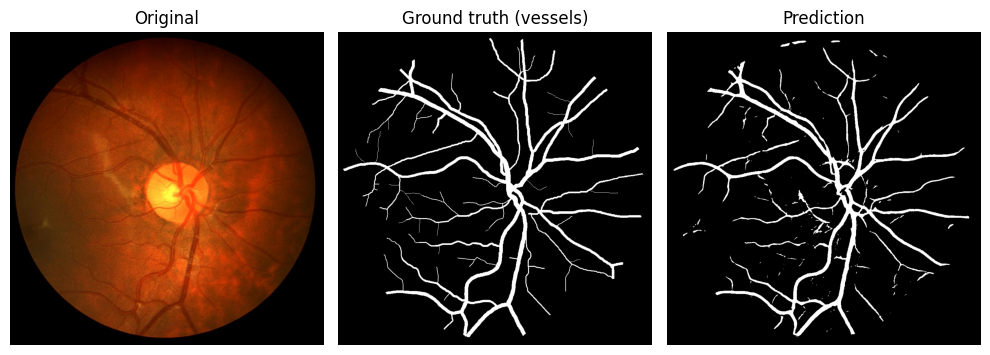

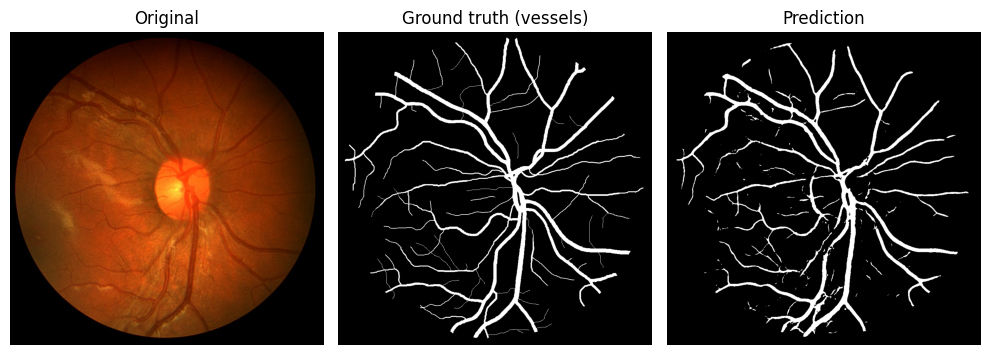

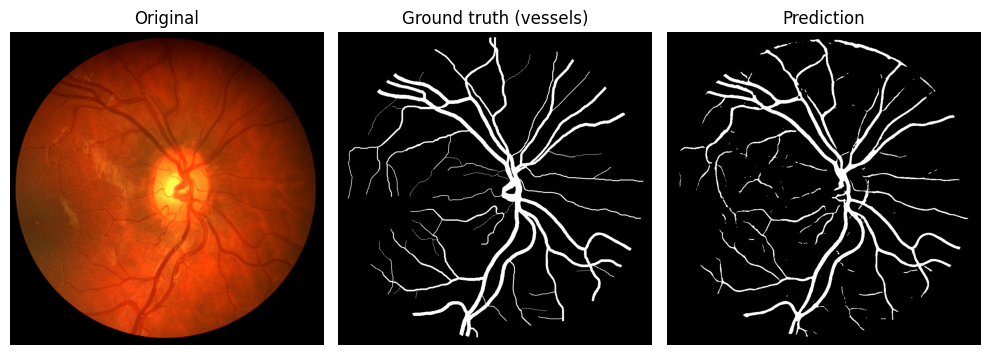

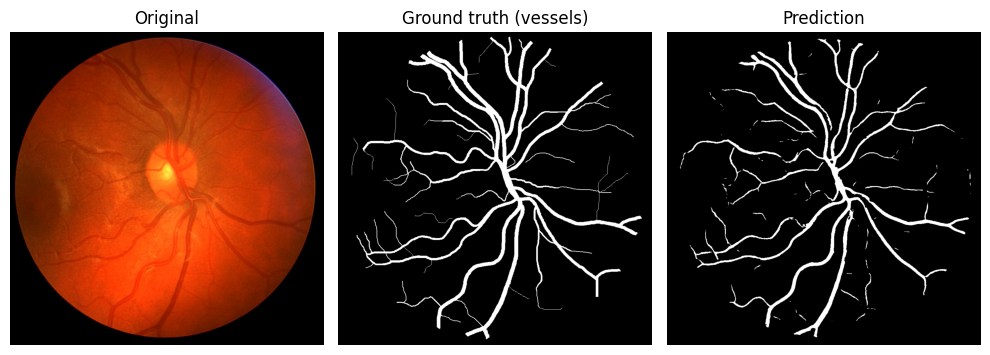

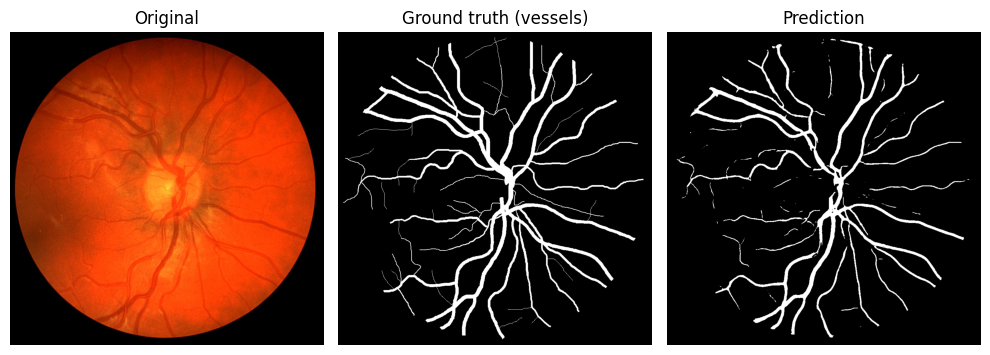

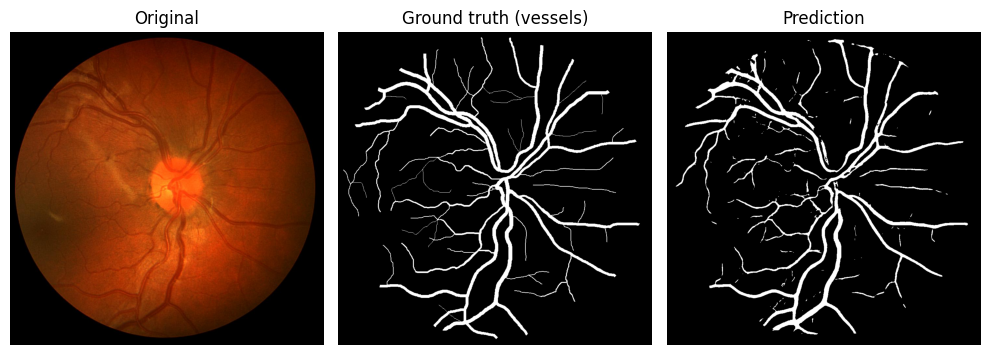

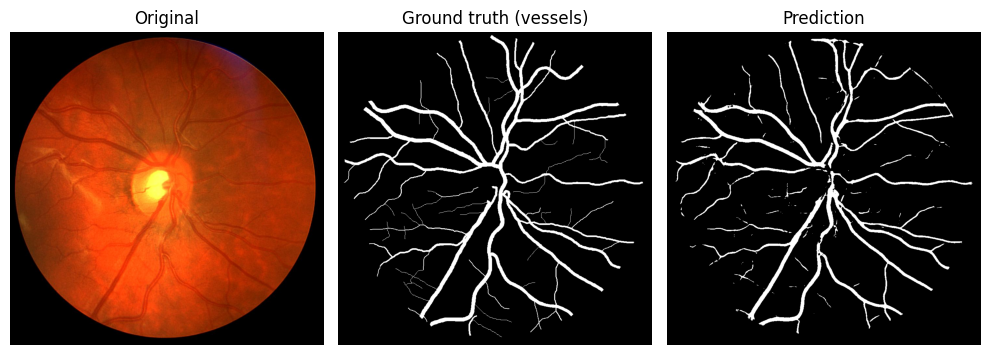

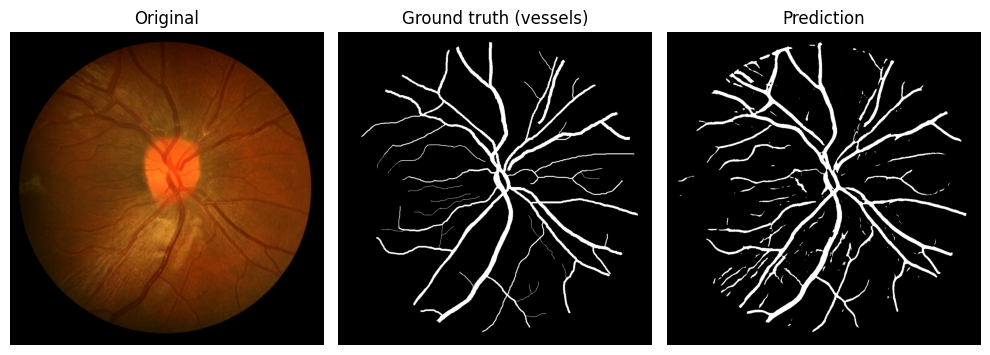

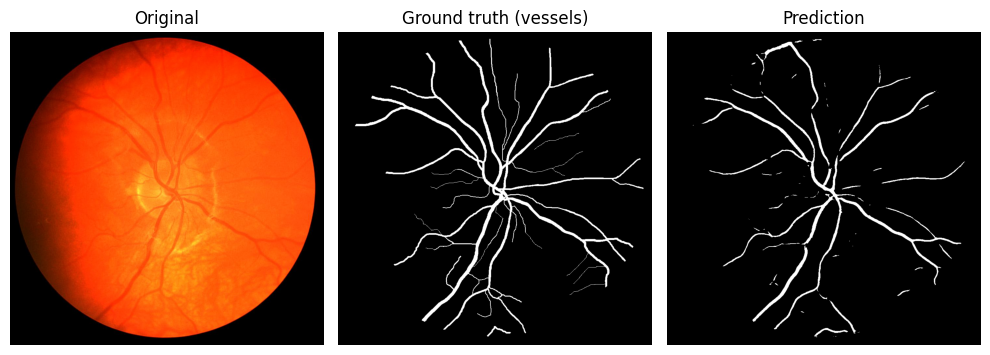

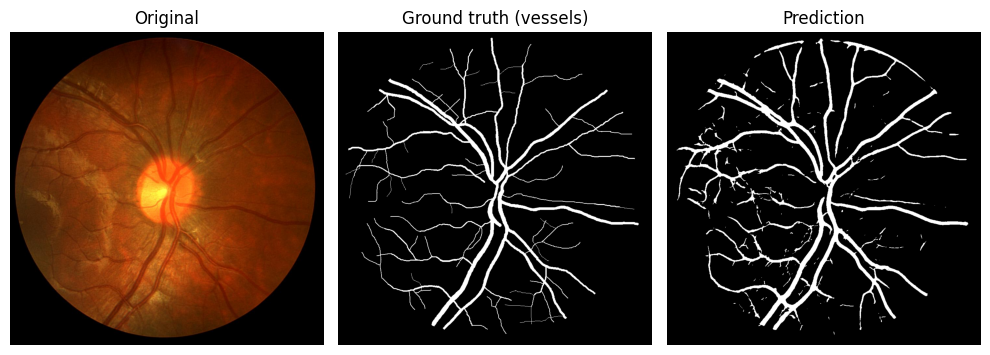

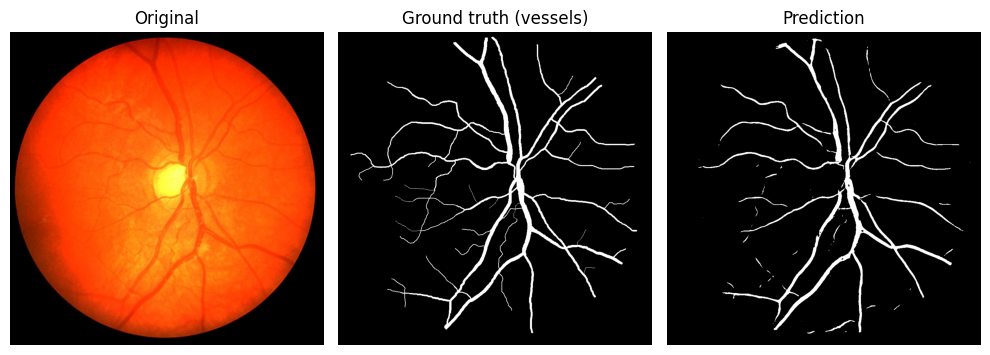

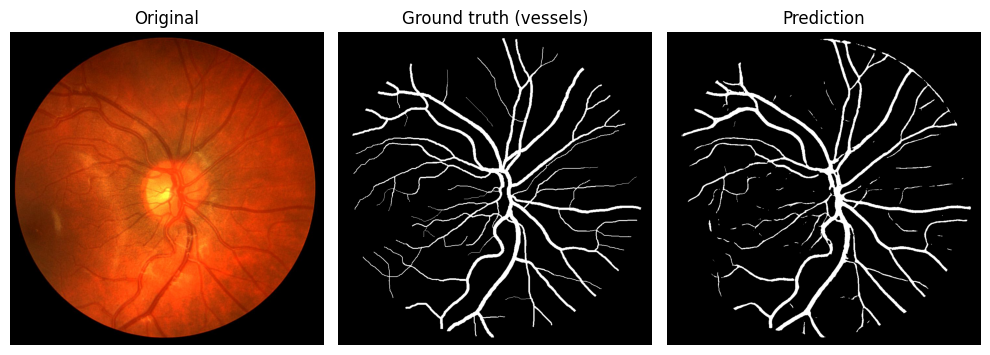

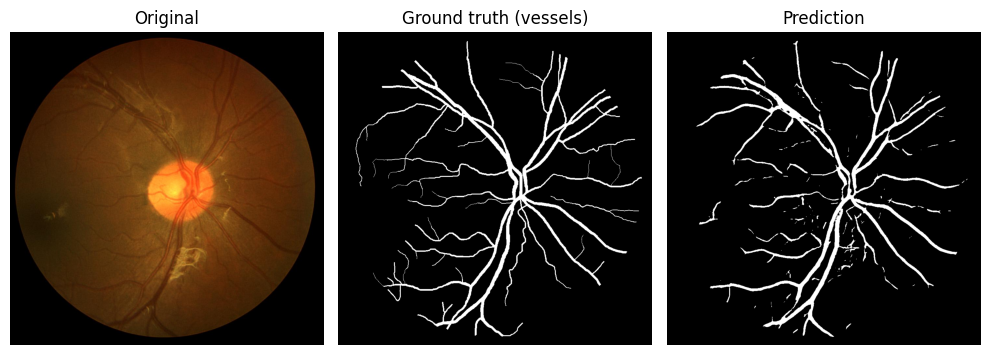

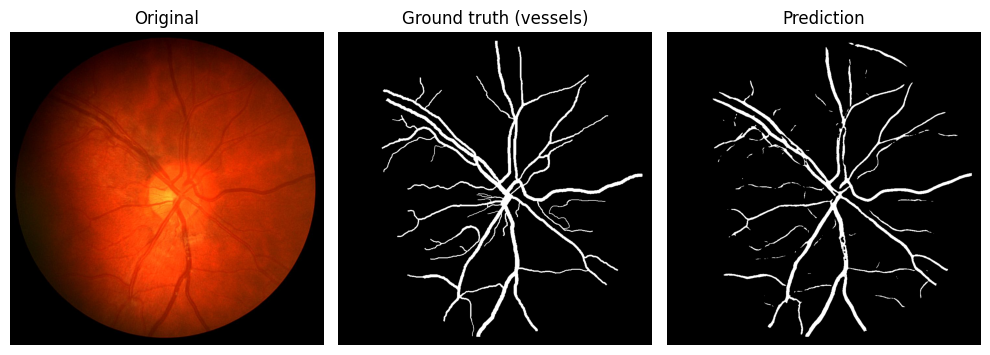

Triplets sauvegardés dans : /home/usrs/hnoel/Tohoku/Monai/SVAR/SVAR_v8/predictions_test_triplets


In [40]:
model.eval()

# 📁 Dossier pour sauvegarder les triplets
pred_dir = data_dir / "predictions_test_triplets"
pred_dir.mkdir(parents=True, exist_ok=True)

img_index = 0

with torch.no_grad():
    for batch in test_loader:
        imgs   = batch["image"].to(device)  # (B,3,H,W)
        labels = batch["label"].to(device)  # (B,1,H,W)

        logits = model(imgs)                # (B,2,H,W)
        if isinstance(logits, list) :
            logits = logits[0]
        preds  = logits.argmax(dim=1)       # (B,H,W)
        targets = labels.squeeze(1)         # (B,H,W)

        for i in range(imgs.size(0)):
            img_i  = imgs[i].cpu()
            gt_i   = targets[i].cpu()
            pred_i = preds[i].cpu()

            fig, ax = plt.subplots(1, 3, figsize=(10, 4))

            ax[0].imshow(img_i.permute(1, 2, 0))
            ax[0].set_title("Original")

            ax[1].imshow(gt_i, cmap="gray")
            ax[1].set_title("Ground truth (vessels)")

            ax[2].imshow(pred_i, cmap="gray")
            ax[2].set_title("Prediction")

            for a in ax:
                a.axis("off")

            plt.tight_layout()

            save_path = pred_dir / f"test_triplet_{img_index:02d}.png"
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            plt.show()

            img_index += 1

print(f"Triplets sauvegardés dans : {pred_dir}")

#### 10.3) Curves

In [41]:
def plot_metric(train_history, val_history, key, title=None, mark_best_on="val_loss", save_folder=data_dir):
    """
    key: nom de la métrique dans les dicts (ex: "loss", "dice", "auc")

    mark_best_on:
        - "val_loss" → marquer l'epoch où val_loss est minimal
        - "val_<key>" → marquer la meilleure valeur validation pour cette métrique (max)
    """

    train = train_history.get(key, [])
    val   = val_history.get(key, [])

    if len(val) == 0:
        print(f"⚠️ Impossible de tracer '{key}' (aucune valeur de validation trouvée)")
        return

    epochs = range(1, len(val) + 1)

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, train, label=f"Train {key}", linewidth=2)
    plt.plot(epochs, val,   label=f"Val {key}", linewidth=2)

    # ======== BEST POINT (scatter) =========
    if mark_best_on == "val_loss" and "loss" in val_history:
        # meilleur = minimum
        best_e = int(np.argmin(val_history["loss"])) + 1
        best_v = val[best_e - 1]
        plt.scatter([best_e], [best_v], s=80, marker="o", color="red", zorder=3,
                    label=f"best @ epoch {best_e}")

    elif mark_best_on == f"val_{key}" and len(val) > 0:
        # meilleur = maximum
        best_e = int(np.nanargmax(val)) + 1
        best_v = val[best_e - 1]
        plt.scatter([best_e], [best_v], s=80, marker="o", color="red", zorder=3,
                    label=f"best @ epoch {best_e}")

    plt.xlabel("Epoch")
    plt.ylabel(key)
    plt.title(title or f"{key} (train vs val)")
    plt.grid(True)
    plt.legend()

    save_path = save_folder / f"{key}.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"💾 Courbe sauvegardée : {save_path}")

    plt.show()

💾 Courbe sauvegardée : /home/usrs/hnoel/Tohoku/Monai/SVAR/SVAR_v8/loss.png


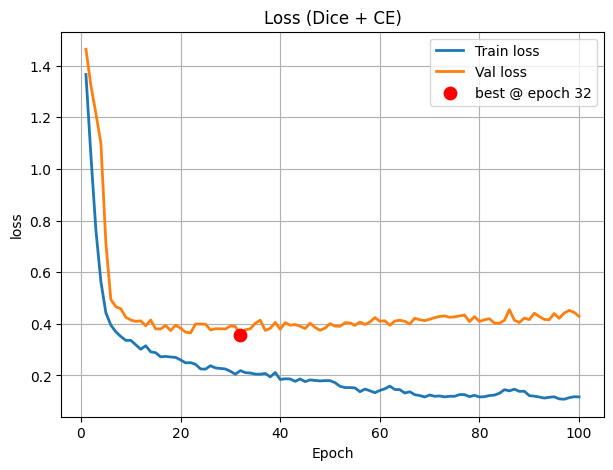

💾 Courbe sauvegardée : /home/usrs/hnoel/Tohoku/Monai/SVAR/SVAR_v8/dice.png


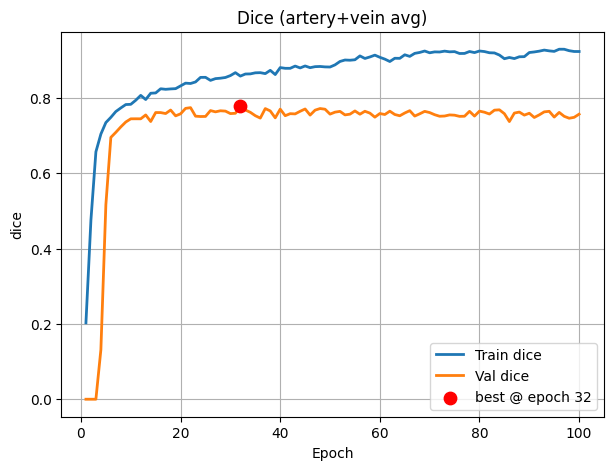

💾 Courbe sauvegardée : /home/usrs/hnoel/Tohoku/Monai/SVAR/SVAR_v8/auc.png


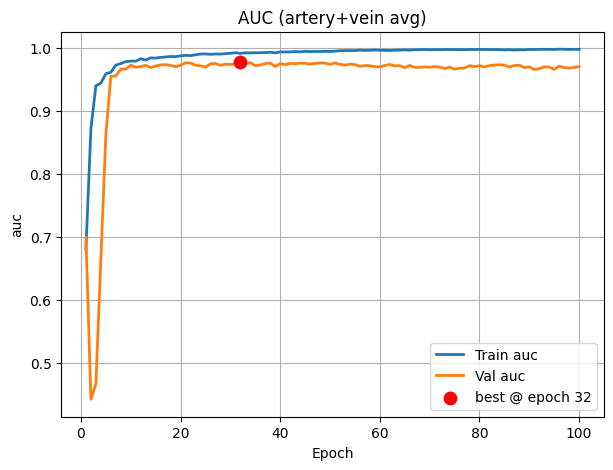

In [42]:
# Loss totale, Dice, AUC : même type de visualisation que dans ton notebook

plot_metric(train_history, val_history, "loss",
            title="Loss (Dice + CE)", mark_best_on="val_loss")

plot_metric(train_history, val_history, "dice",
            title="Dice (artery+vein avg)", mark_best_on="val_dice")

plot_metric(train_history, val_history, "auc",
            title="AUC (artery+vein avg)", mark_best_on="val_auc")

#### 10.3) Table of metrics

In [43]:
# ==== Évaluation globale sur le test ====

model.eval()

conf_sums_test = init_confmat_sums(num_classes=NUM_CLASSES)
auc_buf_test   = init_auc_buffers(classes=[VESSEL_CLASS])

with torch.no_grad():
    for batch in test_loader:
        imgs   = batch["image"].to(device)
        labels = batch["label"].to(device)   # (B,1,H,W)

        logits = model(imgs)
        if isinstance(logits, list) :
            logits = logits[0]                 # (B,2,H,W)
        preds  = logits.argmax(dim=1)        # (B,H,W)
        targets = labels.squeeze(1)          # (B,H,W)

        update_confmat_sums(conf_sums_test, preds, targets, NUM_CLASSES)
        update_auc_buffers(auc_buf_test, logits, targets)

vessel_metrics = compute_scalar_metrics_from_confmat(conf_sums_test, include_classes=[VESSEL_CLASS])
vessel_auc     = compute_mean_auc(auc_buf_test)

results = {
    "Vessel": {
        "accuracy":    vessel_metrics["accuracy"],
        "precision":   vessel_metrics["precision"],
        "recall":      vessel_metrics["recall"],
        "specificity": vessel_metrics["specificity"],
        "dice":        vessel_metrics["dice"],
        "IoU":         vessel_metrics["iou"],
        "AUC":         vessel_auc,
    }
}

df_global = pd.DataFrame(results).T.round(4)

print("\n=== Résultats globaux sur le test (FOV uniquement) ===\n")
display(df_global)

# Sauvegarde en CSV / JSON
metrics_csv_path  = data_dir / "metrics_global_test.csv"
metrics_json_path = data_dir / "metrics_global_test.json"

df_global.to_csv(metrics_csv_path)
df_global.to_json(metrics_json_path, orient="index")

print("→ Sauvegardé :")
print("  ", metrics_csv_path)
print("  ", metrics_json_path)


=== Résultats globaux sur le test (FOV uniquement) ===



,accuracy,precision,recall,specificity,dice,IoU,AUC
Vessel,0.9661,0.77,0.7544,0.9825,0.7621,0.6156,0.9769


→ Sauvegardé :
   /home/usrs/hnoel/Tohoku/Monai/SVAR/SVAR_v8/metrics_global_test.csv
   /home/usrs/hnoel/Tohoku/Monai/SVAR/SVAR_v8/metrics_global_test.json


#### 10.4) Comparaison of the images

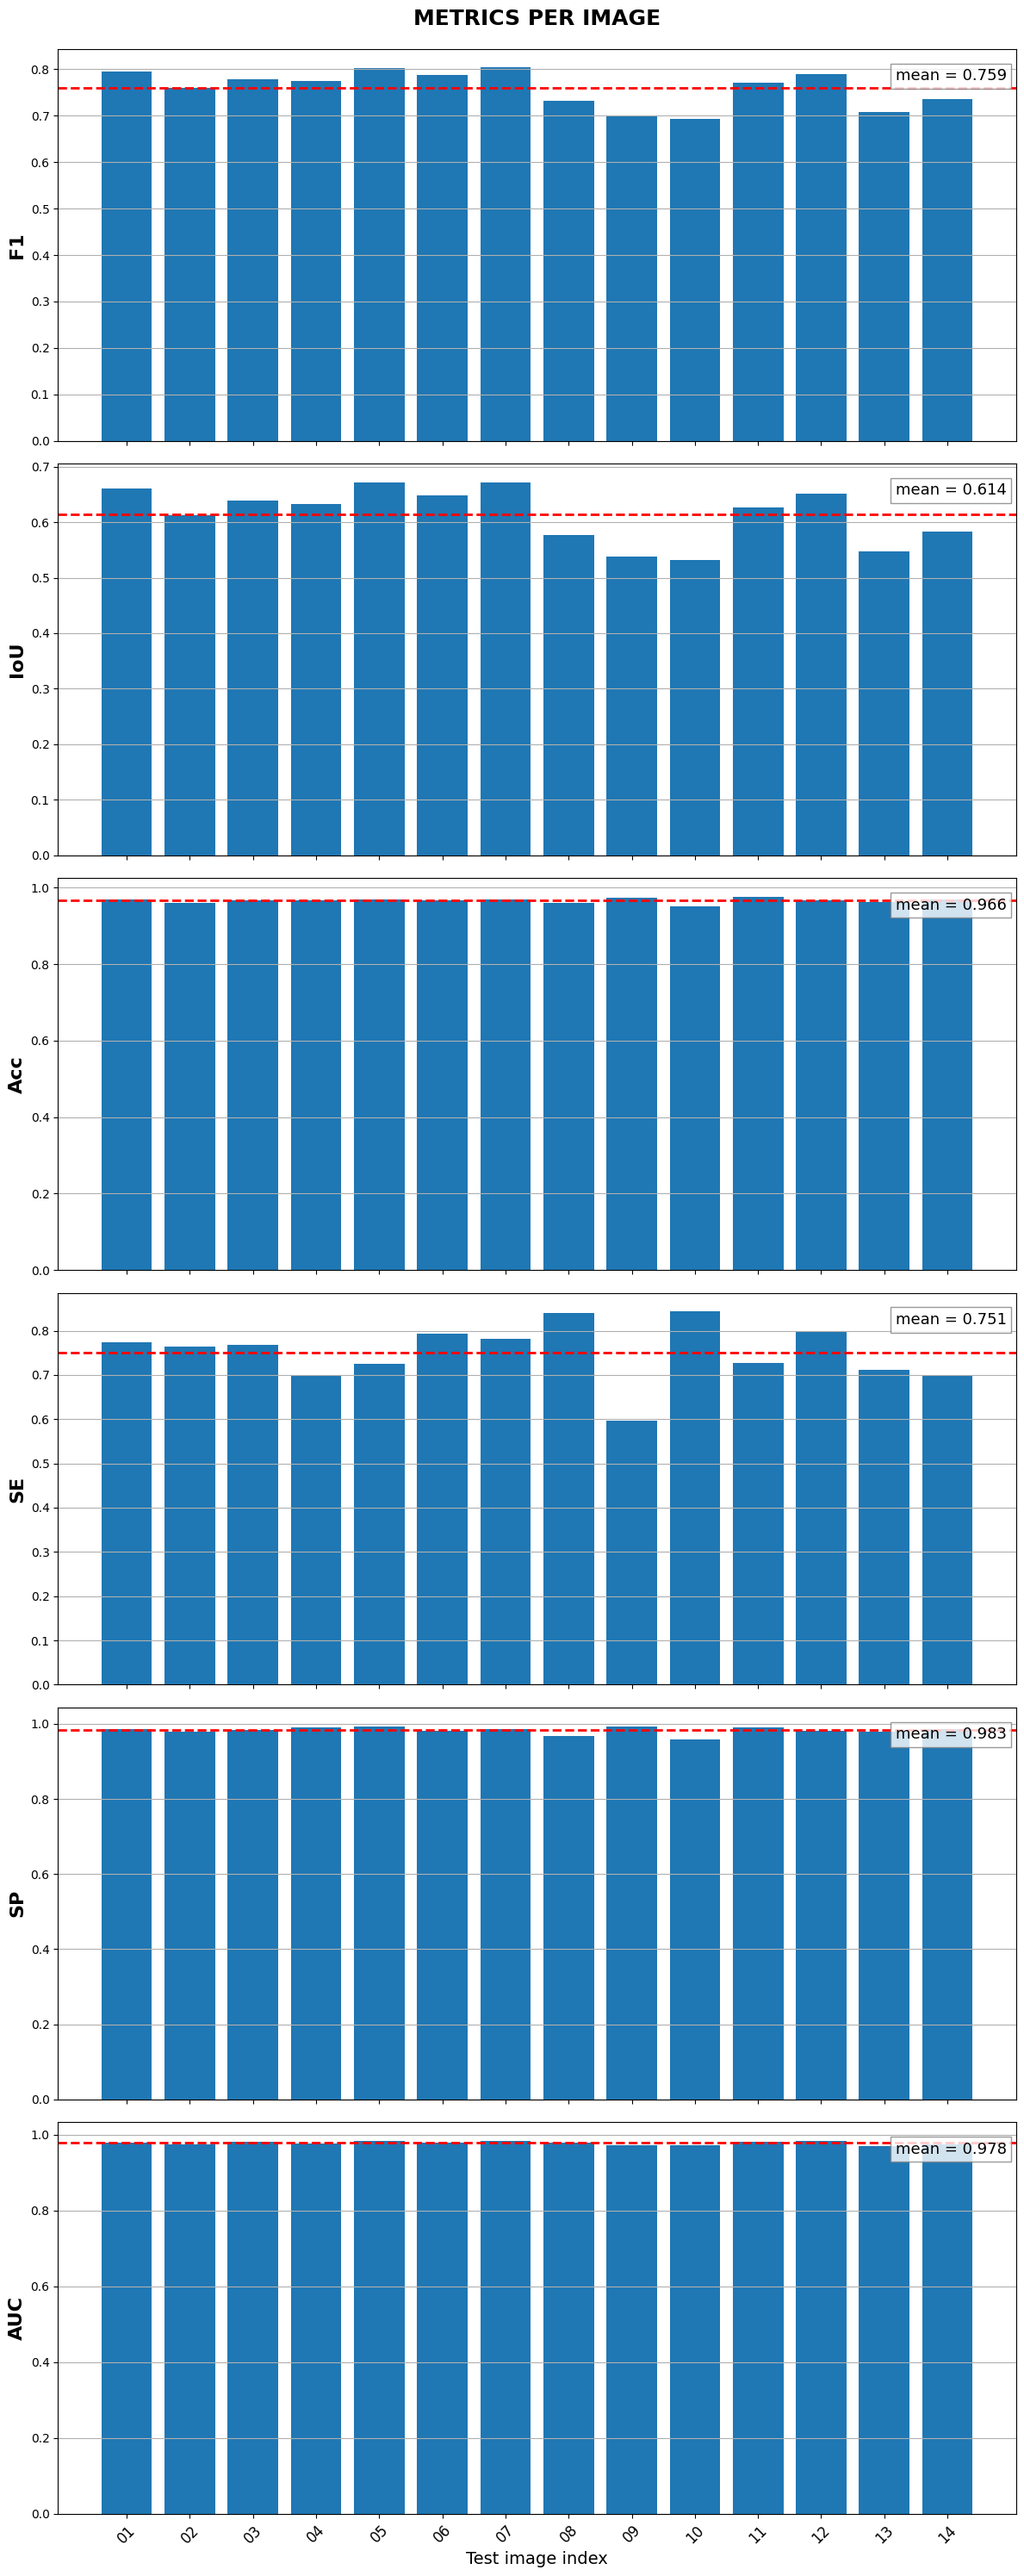

Sauvegardé : /home/usrs/hnoel/Tohoku/Monai/SVAR/SVAR_v8/per_image_metrics.png


In [44]:
# ==========================================================
#   Comparison of the images — Standalone (NO FOV version)
#   Fusion of the 3 original cells — produces final figure
# ==========================================================

# ---- HELPER FUNCTIONS ----

def confusion_binary(pred_bin: torch.Tensor, gt_bin: torch.Tensor):
    pred_bin = pred_bin.bool()
    gt_bin   = gt_bin.bool()
    TP = (pred_bin & gt_bin).sum().item()
    FP = (pred_bin & ~gt_bin).sum().item()
    FN = (~pred_bin & gt_bin).sum().item()
    TN = (~pred_bin & ~gt_bin).sum().item()
    return TP, FP, FN, TN


def metrics_from_conf(TP, FP, FN, TN):
    eps = 1e-7
    Acc  = (TP + TN) / max(TP + TN + FP + FN, eps)
    SE   = TP / max(TP + FN, eps)
    SP   = TN / max(TN + FP, eps)
    Prec = TP / max(TP + FP, eps)
    F1   = 2 * Prec * SE / max(Prec + SE, eps)
    IoU  = TP / max(TP + FP + FN, eps)
    return F1, IoU, Acc, SE, SP


def auc_from_logits_one_class(logits_1img, gt_1img, cls):
    with torch.no_grad():
        probs = F.softmax(logits_1img.unsqueeze(0), dim=1)[0]
        prob_cls = probs[cls]

        y_score = prob_cls.view(-1).cpu().numpy()
        y_true  = (gt_1img.view(-1) == cls).cpu().numpy().astype(np.uint8)

        if (y_true == 1).sum() == 0 or (y_true == 0).sum() == 0:
            return float("nan")

        try:
            return float(roc_auc_score(y_true, y_score))
        except:
            return float("nan")


# ==========================================================
#               METRICS PER IMAGE — FULL IMAGE ONLY
# ==========================================================

model.eval()

metric_names = ["F1", "IoU", "Acc", "SE", "SP", "AUC"]
scores_full = {m: [] for m in metric_names}

img_indices = []

with torch.no_grad():
    current_idx = 0
    for batch in test_loader:
        imgs   = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits  = model(imgs)
        if isinstance(logits, list) :
            logits = logits[0]
        preds   = logits.argmax(dim=1)
        targets = labels.squeeze(1)

        for i in range(imgs.size(0)):
            gt_i   = targets[i]
            pred_i = preds[i]
            log_i  = logits[i]

            pred_v = (pred_i == VESSEL_CLASS)
            gt_v   = (gt_i == VESSEL_CLASS)

            TP, FP, FN, TN = confusion_binary(pred_v, gt_v)
            F1, IoU, Acc, SE, SP = metrics_from_conf(TP, FP, FN, TN)
            AUC = auc_from_logits_one_class(log_i, gt_i, VESSEL_CLASS)

            scores_full["F1"].append(F1)
            scores_full["IoU"].append(IoU)
            scores_full["Acc"].append(Acc)
            scores_full["SE"].append(SE)
            scores_full["SP"].append(SP)
            scores_full["AUC"].append(AUC)

            img_indices.append(current_idx)
            current_idx += 1

# ==========================================================
#               FINAL FIGURE (SAME AS LAST CELL)
#           BUT SINGLE COLUMN (NO FOV IN DATASET)
# ==========================================================

metric_names = ["F1", "IoU", "Acc", "SE", "SP", "AUC"]

fig, axes = plt.subplots(
    nrows=6, ncols=1, figsize=(12, 30), sharex=True
)

axes = axes.ravel()

axes[0].set_title("METRICS PER IMAGE", fontsize=18, fontweight="bold", pad=20)

for row, m in enumerate(metric_names):

    vals = np.array(scores_full[m], dtype=float)
    mean_val = np.nanmean(vals)

    ax = axes[row]
    ax.bar(np.arange(len(vals)), vals)
    ax.axhline(mean_val, color="red", linestyle="--", linewidth=2)

    ax.text(
        0.99, 0.92,
        f"mean = {mean_val:.3f}",
        transform=ax.transAxes,
        horizontalalignment="right",
        fontsize=13,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
    )

    ax.set_ylabel(m, fontsize=16, fontweight="bold")
    ax.grid(True, axis="y")


axes[-1].set_xticks(np.arange(len(vals)))
axes[-1].set_xticklabels(
    [f"{i+1:02d}" for i in range(len(vals))],
    rotation=45,
    fontsize=12
)
axes[-1].set_xlabel("Test image index", fontsize=14)

plt.tight_layout()

out_path = data_dir / "per_image_metrics.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Sauvegardé : {out_path}")


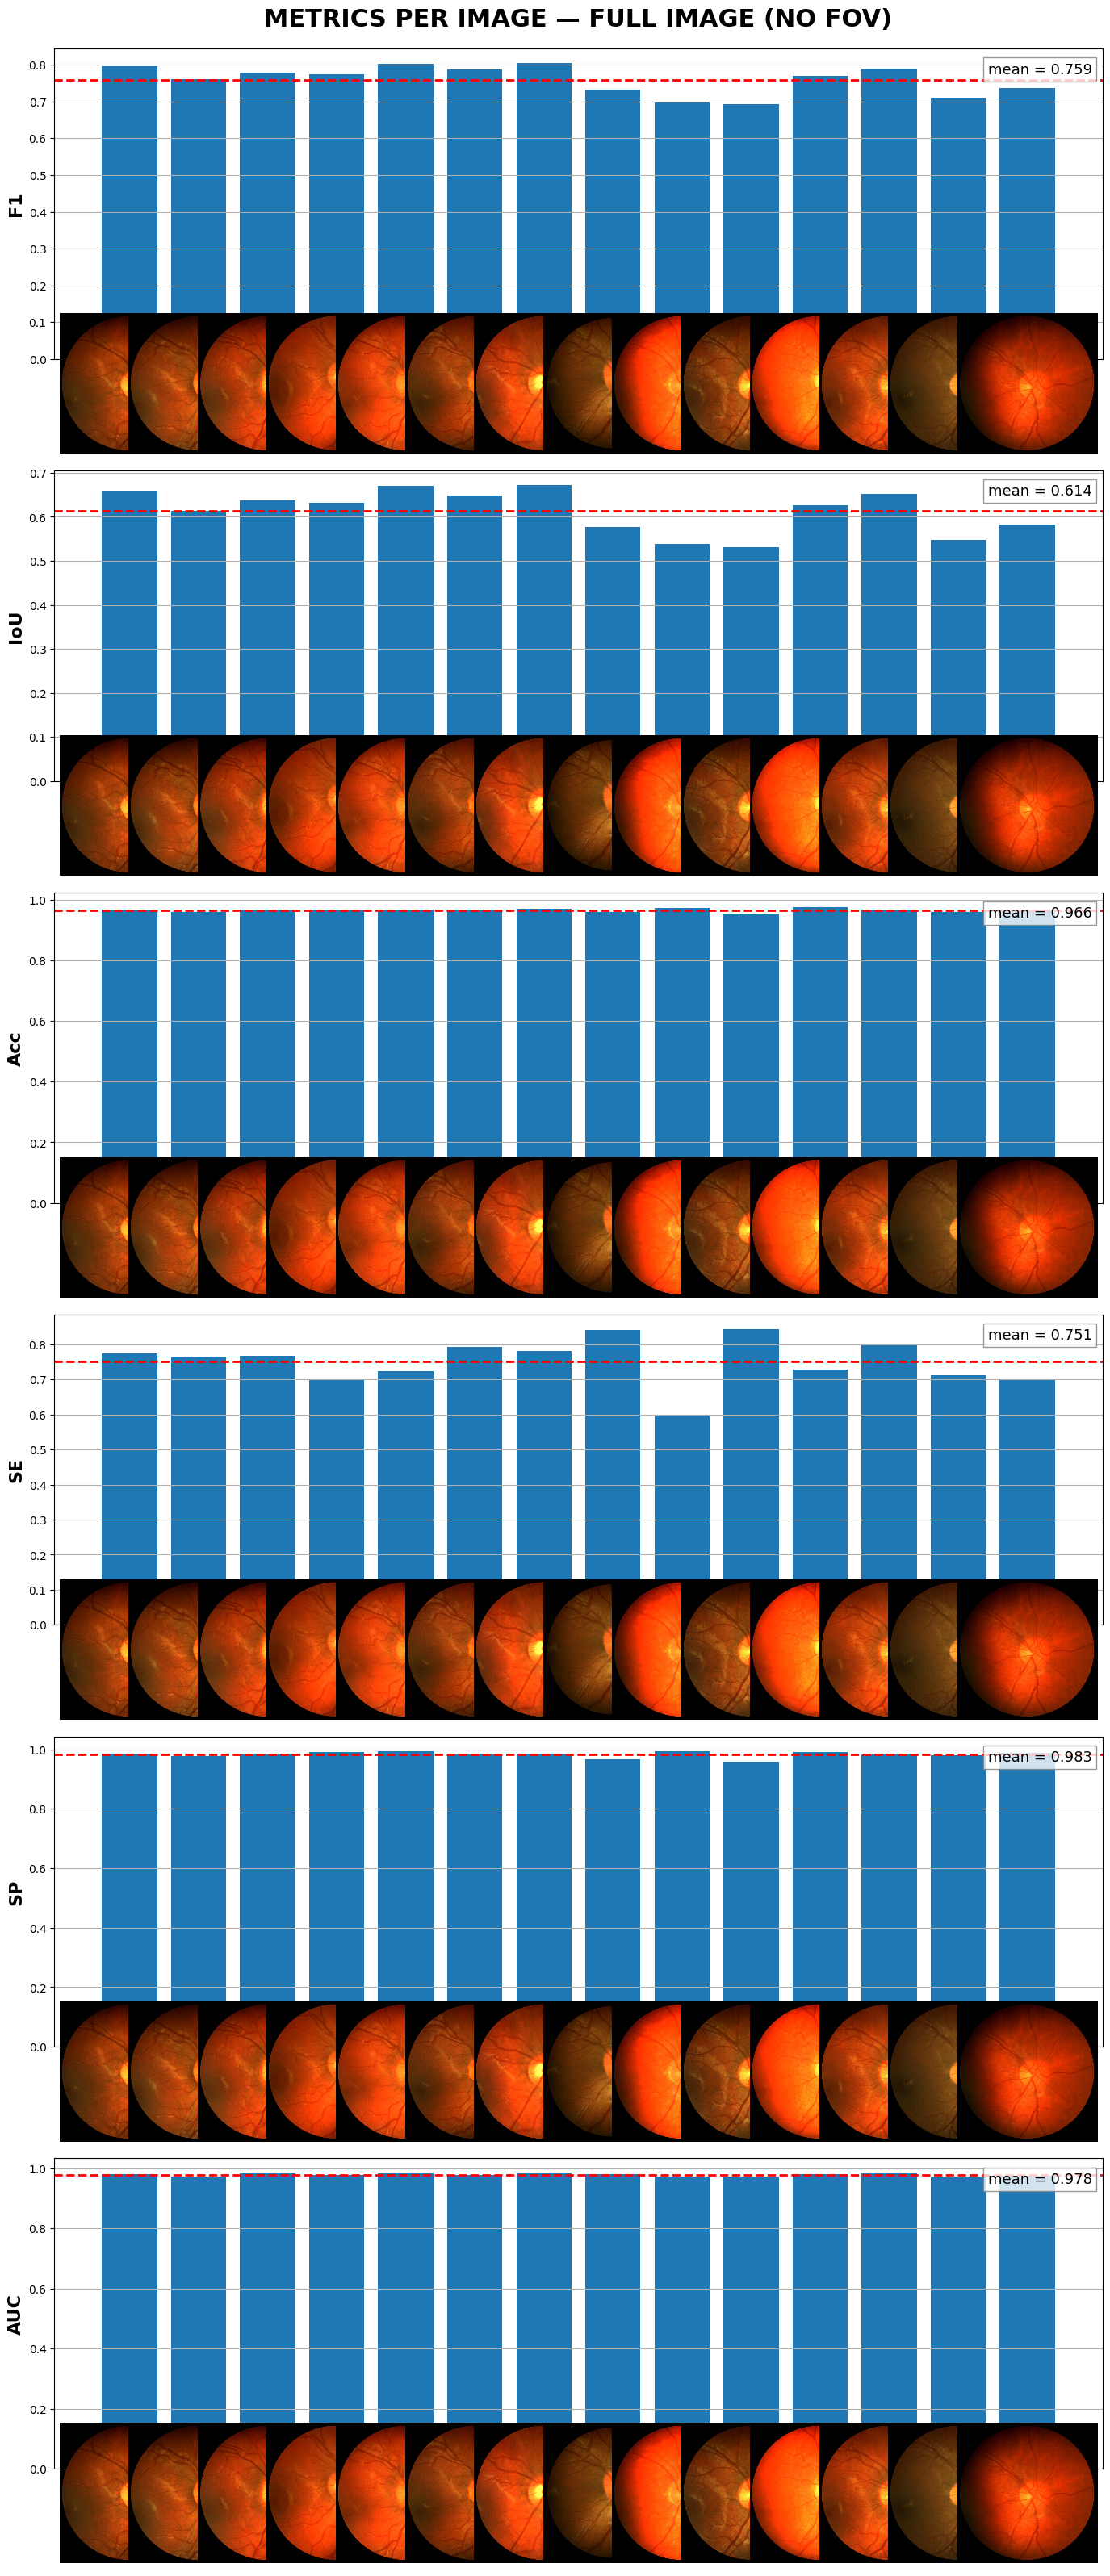

Sauvegardé : /home/usrs/hnoel/Tohoku/Monai/SVAR/SVAR_v8/per_image_metrics_FULLIMAGE_with_thumbnails.png


In [45]:
# ==========================================================
#   Comparison of the images — Standalone (NO FOV)
#   + Images below histogram bars
# ==========================================================

# ---- HELPER FUNCTIONS ----

def confusion_binary(pred_bin: torch.Tensor, gt_bin: torch.Tensor):
    pred_bin = pred_bin.bool()
    gt_bin   = gt_bin.bool()
    TP = (pred_bin & gt_bin).sum().item()
    FP = (pred_bin & ~gt_bin).sum().item()
    FN = (~pred_bin & gt_bin).sum().item()
    TN = (~pred_bin & ~gt_bin).sum().item()
    return TP, FP, FN, TN


def metrics_from_conf(TP, FP, FN, TN):
    eps = 1e-7
    Acc  = (TP + TN) / max(TP + TN + FP + FN, eps)
    SE   = TP / max(TP + FN, eps)
    SP   = TN / max(TN + FP, eps)
    Prec = TP / max(TP + FP, eps)
    F1   = 2 * Prec * SE / max(Prec + SE, eps)
    IoU  = TP / max(TP + FP + FN, eps)
    return F1, IoU, Acc, SE, SP


def auc_from_logits_one_class(logits_1img, gt_1img, cls):
    with torch.no_grad():
        probs = F.softmax(logits_1img.unsqueeze(0), dim=1)[0]
        prob_cls = probs[cls]

        y_score = prob_cls.view(-1).cpu().numpy()
        y_true  = (gt_1img.view(-1) == cls).cpu().numpy().astype(np.uint8)

        if (y_true == 1).sum() == 0 or (y_true == 0).sum() == 0:
            return float("nan")

        try:
            return float(roc_auc_score(y_true, y_score))
        except:
            return float("nan")


# ==========================================================
#               METRICS PER IMAGE — FULL IMAGE ONLY
# ==========================================================

model.eval()

metric_names = ["F1", "IoU", "Acc", "SE", "SP", "AUC"]
scores_full = {m: [] for m in metric_names}
img_indices = []
all_images = []  # stockage des images brutes pour affichage

with torch.no_grad():
    current_idx = 0
    for batch in test_loader:
        imgs   = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits  = model(imgs)
        if isinstance(logits, list) :
            logits = logits[0]
        preds   = logits.argmax(dim=1)
        targets = labels.squeeze(1)

        for i in range(imgs.size(0)):
            gt_i   = targets[i]
            pred_i = preds[i]
            log_i  = logits[i]

            # Sauvegarde image originale pour affichage
            all_images.append(imgs[i].cpu().permute(1, 2, 0).numpy())

            pred_v = (pred_i == VESSEL_CLASS)
            gt_v   = (gt_i == VESSEL_CLASS)

            TP, FP, FN, TN = confusion_binary(pred_v, gt_v)
            F1, IoU, Acc, SE, SP = metrics_from_conf(TP, FP, FN, TN)
            AUC = auc_from_logits_one_class(log_i, gt_i, VESSEL_CLASS)

            scores_full["F1"].append(F1)
            scores_full["IoU"].append(IoU)
            scores_full["Acc"].append(Acc)
            scores_full["SE"].append(SE)
            scores_full["SP"].append(SP)
            scores_full["AUC"].append(AUC)

            img_indices.append(current_idx)
            current_idx += 1

# ==========================================================
#                FINAL FIGURE WITH IMAGES UNDER BARS
# ==========================================================

metric_names = ["F1", "IoU", "Acc", "SE", "SP", "AUC"]

fig, axes = plt.subplots(
    nrows=6, ncols=1, figsize=(14, 32), sharex=True
)

axes = axes.ravel()

axes[0].set_title("METRICS PER IMAGE — FULL IMAGE (NO FOV)", fontsize=22, fontweight="bold", pad=20)

n_images = len(all_images)
x = np.arange(n_images)

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def add_image_under_bar(ax, img, xpos, y_bottom):
    imagebox = OffsetImage(img, zoom=0.13)
    ab = AnnotationBbox(imagebox, (xpos, y_bottom - 0.08),
                        xycoords=("data", "axes fraction"),
                        frameon=False)
    ax.add_artist(ab)

for row, m in enumerate(metric_names):

    vals = np.array(scores_full[m], dtype=float)
    mean_val = np.nanmean(vals)

    ax = axes[row]
    bars = ax.bar(x, vals)

    # Ligne de moyenne
    ax.axhline(mean_val, color="red", linestyle="--", linewidth=2)
    ax.text(
        0.99, 0.92,
        f"mean = {mean_val:.3f}",
        transform=ax.transAxes,
        horizontalalignment="right",
        fontsize=13,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
    )

    # Ajout des images sous chaque barre
    for j in range(n_images):
        img = all_images[j]
        add_image_under_bar(ax, img, j, 0)

    ax.set_ylabel(m, fontsize=16, fontweight="bold")
    ax.grid(True, axis="y")

axes[-1].set_xticks(x)
axes[-1].set_xticklabels([f"{i+1:02d}" for i in x], rotation=45, fontsize=12)
axes[-1].set_xlabel("Test image index", fontsize=14)

plt.tight_layout()

out_path = data_dir / "per_image_metrics_FULLIMAGE_with_thumbnails.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Sauvegardé : {out_path}")


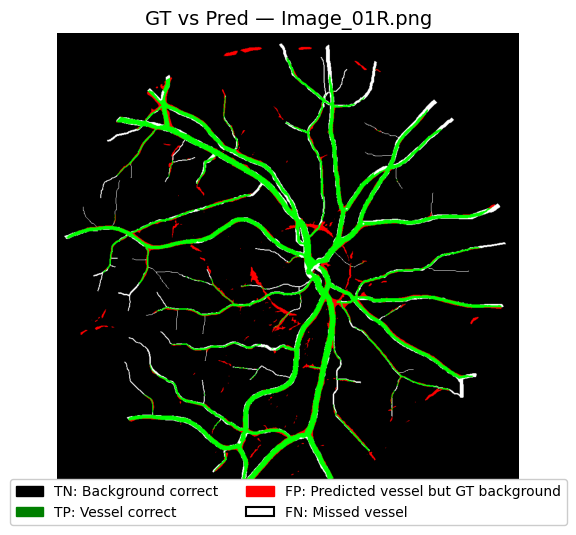

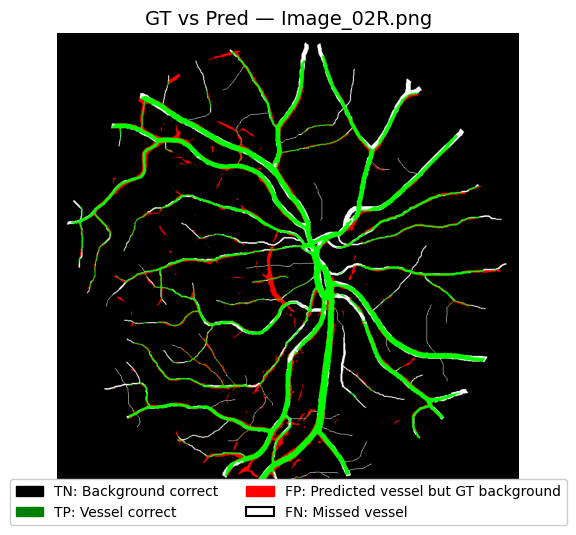

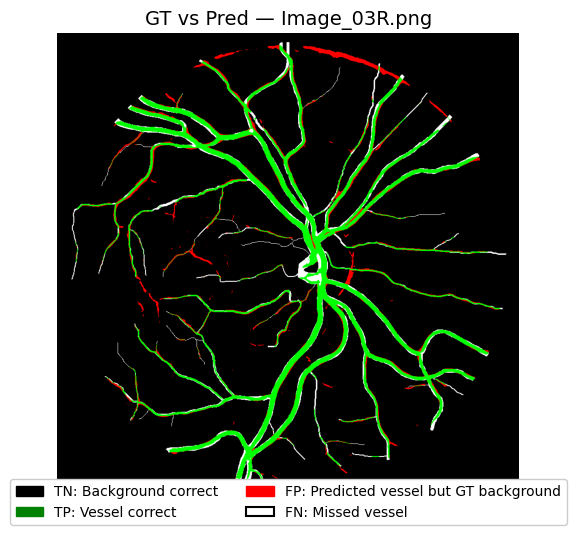

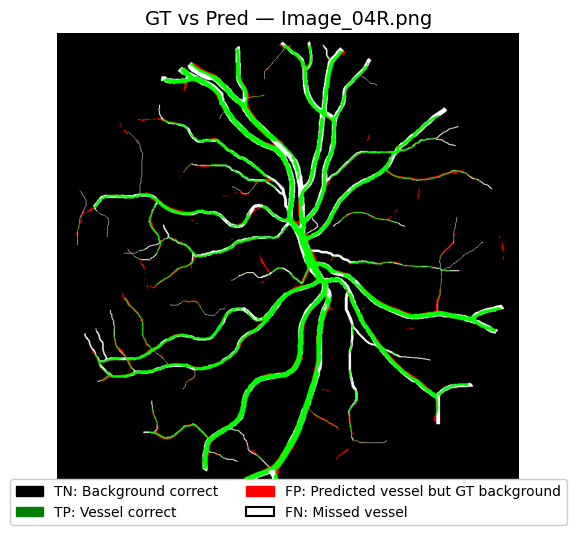

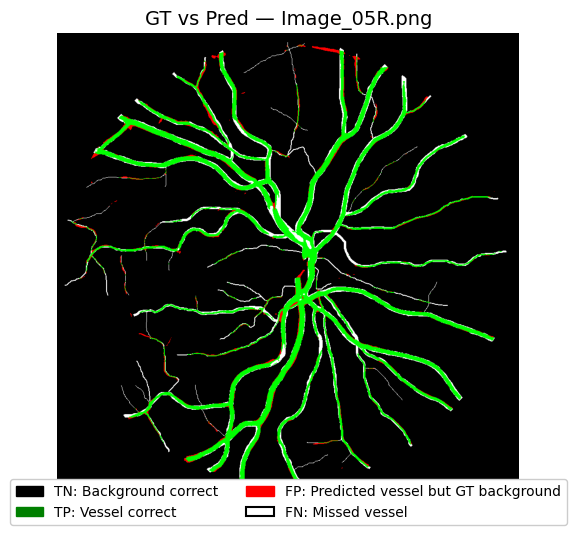

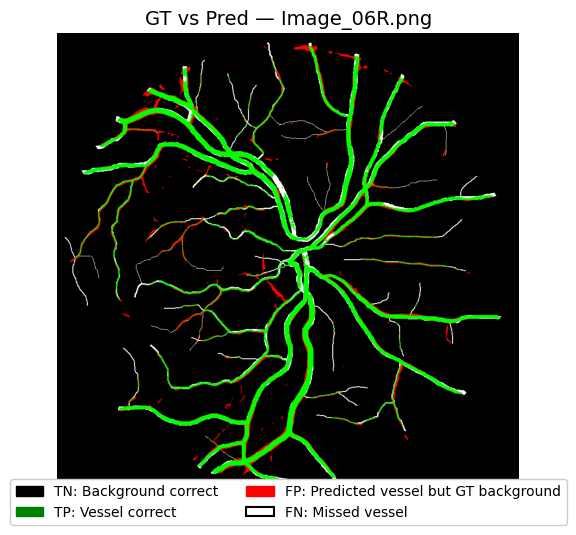

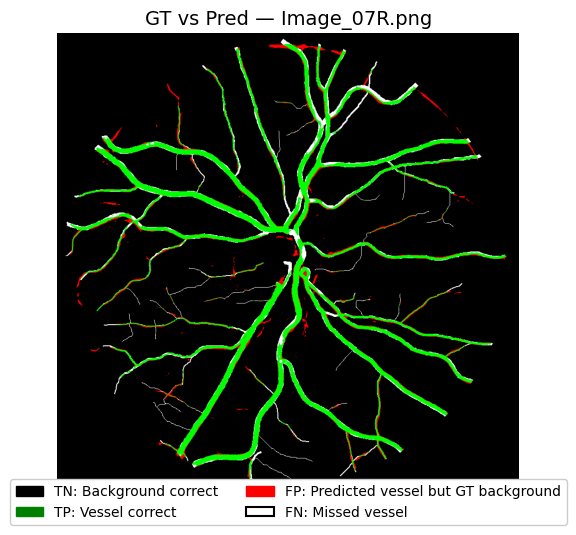

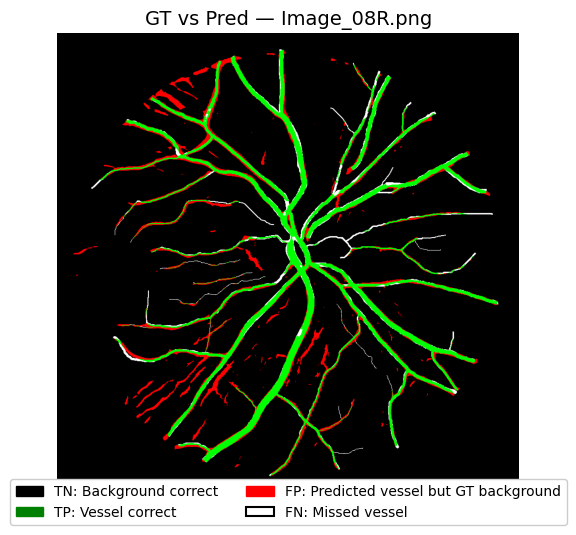

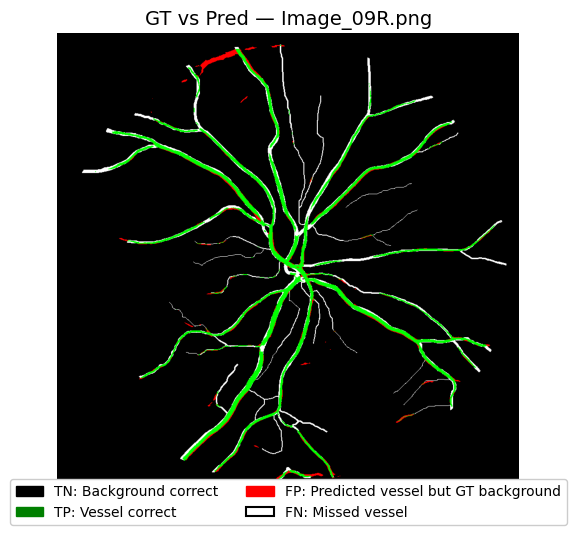

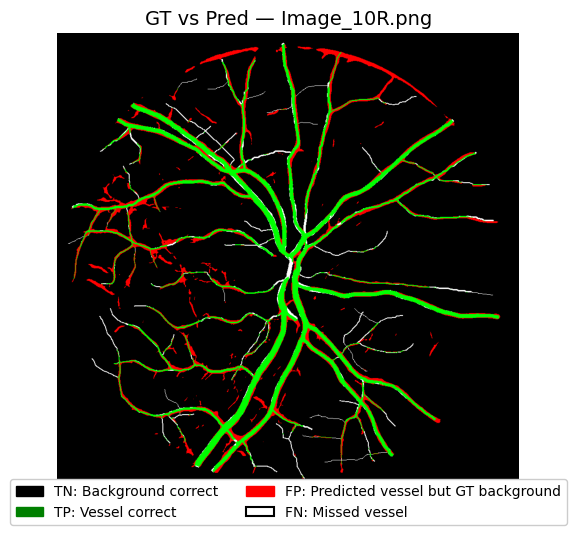

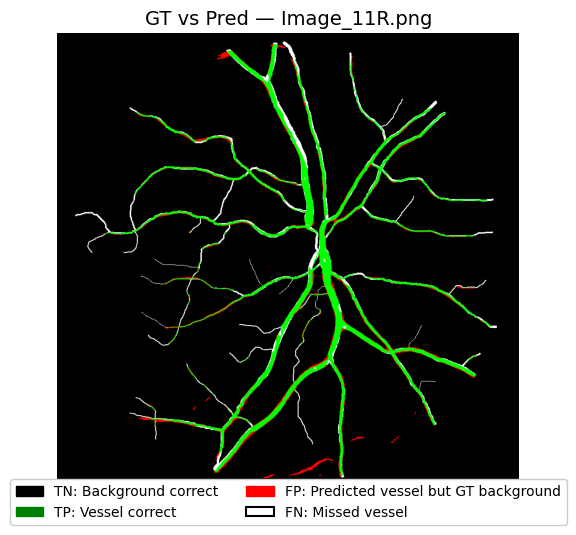

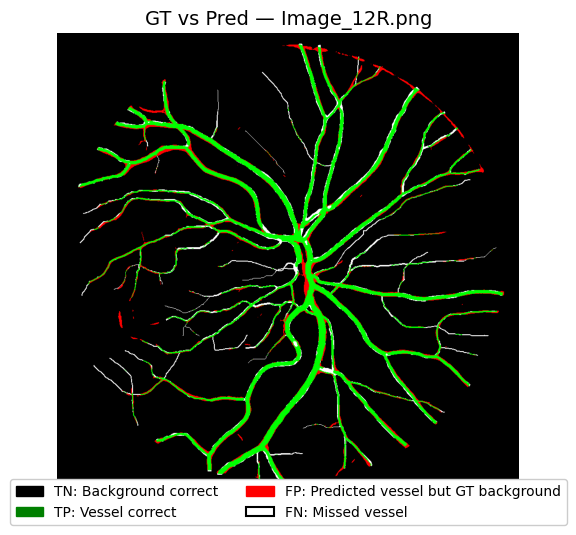

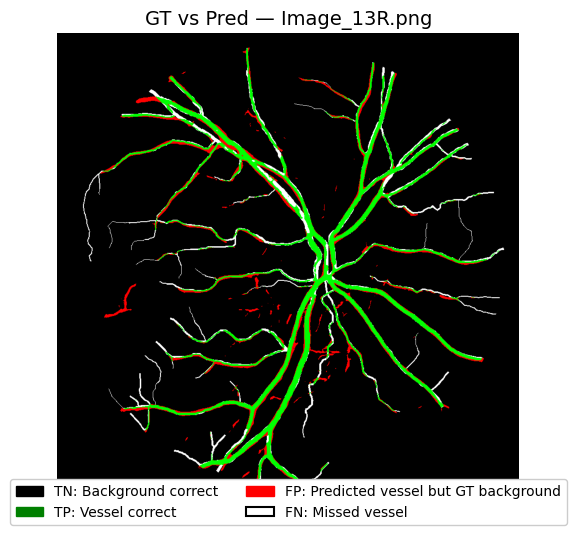

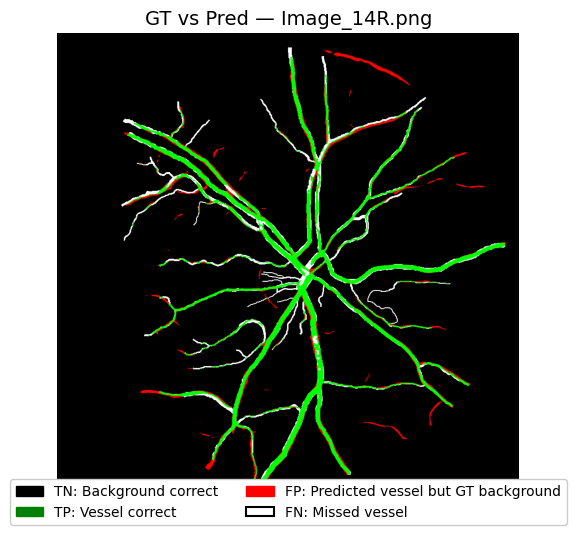

Overlays enregistrés dans : /home/usrs/hnoel/Tohoku/Monai/SVAR/SVAR_v8/overlays_test


In [46]:
# ==========================================================
#   Overlay GT vs Pred — With legend, filenames, saving
# ==========================================================

model.eval()

# 📁 Dossier pour sauvegarder les overlays
overlay_dir = data_dir / "overlays_test"
overlay_dir.mkdir(parents=True, exist_ok=True)

# Pour récupérer le nom réel des fichiers test (triés)
test_img_paths = sorted(list(test_images_dir.glob("*.png")))

with torch.no_grad():
    for idx, batch in enumerate(test_loader):
        imgs    = batch["image"].to(device)      # (B,3,H,W)
        labels  = batch["label"].to(device)      # (B,1,H,W)
        logits  = model(imgs)
        if isinstance(logits, list) :
            logits = logits[0]
        preds   = logits.argmax(dim=1)
        targets = labels.squeeze(1)

        batch_size = imgs.size(0)

        for i in range(batch_size):

            # Récupérer nom réel du fichier
            global_index = idx * batch_size + i
            img_name = test_img_paths[global_index].name

            # Tensors -> numpy
            gt  = (targets[i].cpu().numpy() == VESSEL_CLASS).astype(np.uint8)
            pr  = (preds[i].cpu().numpy()    == VESSEL_CLASS).astype(np.uint8)
            H, W = gt.shape

            # Overlay RGB
            overlay = np.zeros((H, W, 3), dtype=float)

            # TN (0,0) → noir
            mask_tn = (gt == 0) & (pr == 0)
            overlay[mask_tn] = [0, 0, 0]

            # TP (1,1) → vert
            mask_tp = (gt == 1) & (pr == 1)
            overlay[mask_tp] = [0, 1, 0]

            # FP (0,1) → rouge
            mask_fp = (gt == 0) & (pr == 1)
            overlay[mask_fp] = [1, 0, 0]

            # FN (1,0) → blanc
            mask_fn = (gt == 1) & (pr == 0)
            overlay[mask_fn] = [1, 1, 1]

            # ======== FIGURE ========
            fig, ax = plt.subplots(figsize=(6, 6))
            ax.imshow(overlay)
            ax.axis("off")
            ax.set_title(f"GT vs Pred — {img_name}", fontsize=14)

            # ======== LÉGENDE ========
            # On crée une "fake" légende avec des patches colorés
            import matplotlib.patches as mpatches
            legend_elems = [
                mpatches.Patch(color="black", label="TN: Background correct"),
                mpatches.Patch(color="green", label="TP: Vessel correct"),
                mpatches.Patch(color="red",   label="FP: Predicted vessel but GT background"),
                mpatches.Patch(facecolor="white", edgecolor="black", linewidth=1.5, label="FN: Missed vessel")
,
            ]
            ax.legend(handles=legend_elems, loc="lower center",
                      bbox_to_anchor=(0.5, -0.08),
                      fancybox=True, framealpha=1,
                      ncol=2)

            # ======== SAUVEGARDE ========
            save_path = overlay_dir / f"overlay_{global_index:02d}.png"
            plt.savefig(save_path, dpi=200, bbox_inches="tight")
            plt.show()

print(f"Overlays enregistrés dans : {overlay_dir}")
